In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
bat1_path ="/content/drive/MyDrive/Donnee_nasa_IVT/battery1.pkl"
bat2_path ="/content/drive/MyDrive/Donnee_nasa_IVT/battery2.pkl"
bat3_path ="/content/drive/MyDrive/Donnee_nasa_IVT/battery3.pkl"
bat4_path ="/content/drive/MyDrive/Donnee_nasa_IVT/battery4.pkl"

save_path = "/content/drive/MyDrive/Donnee_nasa_IVT/"

In [3]:
import pandas as pd

battery1_df = pd.read_pickle(bat1_path)
battery2_df = pd.read_pickle(bat2_path)
battery3_df = pd.read_pickle(bat3_path)
battery4_df = pd.read_pickle(bat4_path)

print("Battrie 1 colonnes : ", battery1_df.columns)
print("Battrie 2 colonnes : ", battery2_df.columns)
print("Battrie 3 colonnes : ", battery3_df.columns)
print("Battrie 4 colonnes : ", battery4_df.columns)

Battrie 1 colonnes :  Index(['CourantX', 'E11', 'TemperatureX', 'TimeX', 'VoltageX', 'Y11'], dtype='object')
Battrie 2 colonnes :  Index(['CourantX1', 'E12', 'TemperatureX1', 'TimeX1', 'VoltageX1', 'Y12'], dtype='object')
Battrie 3 colonnes :  Index(['CourantX2', 'E13', 'TemperatureX2', 'TimeX2', 'VoltageX2', 'Y13'], dtype='object')
Battrie 4 colonnes :  Index(['CourantX3', 'E14', 'TemperatureX3', 'TimeX3', 'VoltageX3', 'Y14'], dtype='object')


In [4]:
print("\n====== Sahpes ======")

print(battery1_df.shape)
print(battery2_df.shape)
print(battery3_df.shape)
print(battery4_df.shape)

battery1_df.head()


====== Sahpes ======
(39, 6)
(39, 6)
(39, 6)
(39, 6)


,CourantX,E11,TemperatureX,TimeX,VoltageX,Y11
0,"[[1.503, 1.5, 1.499, 1.5, 1.5, 1.5, 1.5, 1.499...",[[7.567279857419445]],"[[22.7617, 22.7617, 22.7617, 22.7617, 22.77732...","[[0.04, 1.04, 2.04, 3.04, 4.04, 5.04, 6.04, 7....","[[4.068, 4.063, 4.061, 4.058, 4.057, 4.055, 4....",[[2.042708431944445]]
1,"[[-3.639, 0.752, 0.75, 0.75, 0.75, 0.75, 0.75,...",[[7.322029103750001]],"[[22.30897, 22.30897, 22.30897, 22.30897, 22.3...","[[0.01, 0.04, 1.04, 2.04, 3.04, 4.04, 5.04, 6....","[[4.501, 4.131, 4.128, 4.126, 4.125, 4.124, 4....",[[1.9815617722222223]]
2,"[[-0.628, 2.253, 2.251, 2.25, 2.25, 2.25, 2.25...",[[7.043500541666667]],"[[22.52753, 22.54314, 22.54314, 22.54314, 22.5...","[[0.01, 0.04, 1.04, 2.04, 3.04, 4.04, 5.04, 6....","[[4.25, 3.992, 3.98, 3.975, 3.972, 3.968, 3.96...",[[1.910396527777778]]
3,"[[-3.639, 4.502, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5,...",[[6.82224638125]],"[[22.40264, 22.40264, 22.40264, 22.40264, 22.4...","[[0.01, 0.04, 1.04, 2.04, 3.04, 4.04, 5.04, 6....","[[4.507, 3.778, 3.752, 3.742, 3.733, 3.725, 3....",[[1.854691666666667]]
4,"[[1.505, 1.5, 1.5, 1.5, 1.5, 1.5, 1.499, 1.499...",[[6.465423250555555]],"[[21.79379, 21.79379, 21.79379, 21.79379, 21.7...","[[0.04, 1.04, 2.04, 3.04, 4.04, 5.04, 6.04, 7....","[[4.054, 4.043, 4.04, 4.037, 4.035, 4.032, 4.0...",[[1.762265527777778]]


# Uniformiser les noms des colonnes

In [5]:
list_df = [battery1_df, battery2_df, battery3_df, battery4_df]
new_columns = ['Courant', 'E', 'Temperature', 'Time', 'Voltage', 'Y']

for i in range(len(list_df)):
    list_df[i].columns = new_columns

print("Battrie 1 colonnes : ", battery1_df.columns)
print("Battrie 2 colonnes : ", battery2_df.columns)
print("Battrie 3 colonnes : ", battery3_df.columns)
print("Battrie 4 colonnes : ", battery4_df.columns)

Battrie 1 colonnes :  Index(['Courant', 'E', 'Temperature', 'Time', 'Voltage', 'Y'], dtype='object')
Battrie 2 colonnes :  Index(['Courant', 'E', 'Temperature', 'Time', 'Voltage', 'Y'], dtype='object')
Battrie 3 colonnes :  Index(['Courant', 'E', 'Temperature', 'Time', 'Voltage', 'Y'], dtype='object')
Battrie 4 colonnes :  Index(['Courant', 'E', 'Temperature', 'Time', 'Voltage', 'Y'], dtype='object')


In [6]:
print("Type of CourantX varaible : ",type(battery1_df['Courant'].iloc[0]))
print(battery1_df['Courant'].iloc[0].shape)

Type of CourantX varaible :  <class 'numpy.ndarray'>
(1, 336219)


# Extract only the last 5000 points


In [7]:
import numpy as np

def extract_last_5000(x):
    if isinstance(x, (list, np.ndarray)):
        return x[-5000:] if len(x) >= 5000 else x
    return x

def force_5000(x):
    if isinstance(x, (list, np.ndarray)):
        x = np.array(x).flatten()
        if len(x) >= 5000:
            return x[-5000:]
        else:
            pad_length = 5000 - len(x)
            pad_values = np.full(pad_length, np.mean(x) if len(x) > 0 else 0.0)
            return np.concatenate([x, pad_values])
    return np.full(5000, 0.0)

for col in ['Courant', 'Temperature', 'Voltage' , 'Time' ]:
    battery1_df[col] = battery1_df[col].apply(force_5000)
    battery2_df[col] = battery2_df[col].apply(force_5000)
    battery3_df[col] = battery3_df[col].apply(force_5000)
    battery4_df[col] = battery4_df[col].apply(force_5000)


print("taille de Courant[0] : " , battery1_df['Courant'].iloc[i].shape)
import numpy as np
print(np.max(battery1_df['Courant'].iloc[0]))


taille de Courant[0] :  (5000,)
4.504


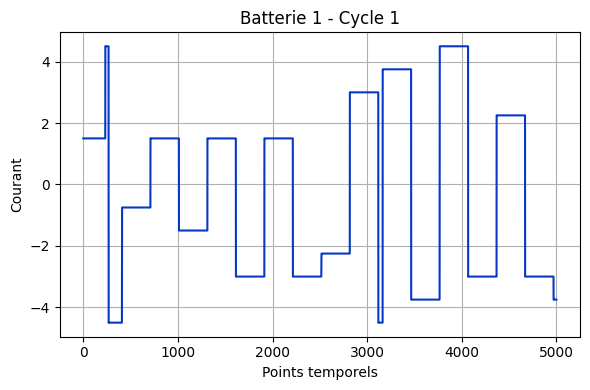

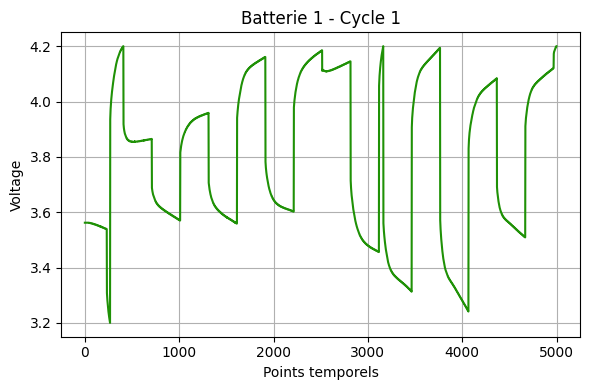

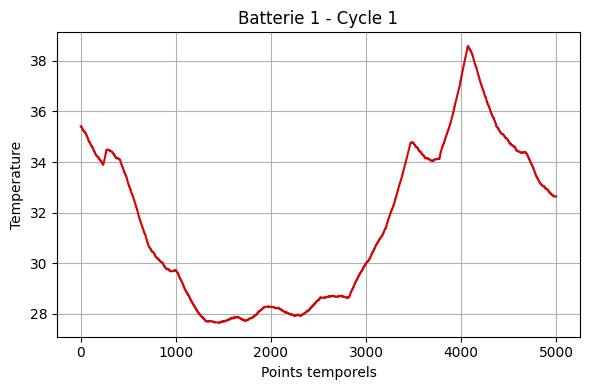

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(battery1_df['Courant'].iloc[0] , color = '#0638c6')
plt.title("Batterie 1 - Cycle 1")
plt.xlabel("Points temporels")
plt.ylabel("Courant")
plt.grid(True)
plt.tight_layout()
plt.show()


import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(battery1_df['Voltage'].iloc[0] , color = '#1f9106')
plt.title("Batterie 1 - Cycle 1")
plt.xlabel("Points temporels")
plt.ylabel("Voltage")
plt.grid(True)
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(battery1_df['Temperature'].iloc[0] , color = '#d30707')
plt.title("Batterie 1 - Cycle 1")
plt.xlabel("Points temporels")
plt.ylabel("Temperature")
plt.grid(True)
plt.tight_layout()
plt.show()


# Capacity (Y)

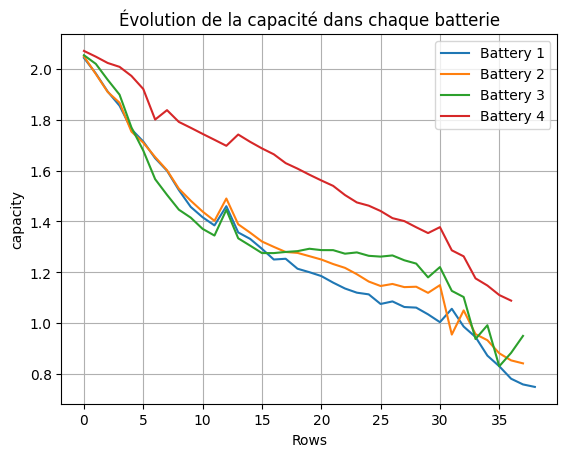

In [9]:
import matplotlib.pyplot as plt


batteries = [battery1_df , battery2_df , battery3_df , battery4_df]
for i, battery in enumerate(batteries):
    soh = battery['Y'].values
    plt.plot(soh, label=f'Battery {i+1}')
plt.title("Évolution de la capacité dans chaque batterie")
plt.xlabel("Rows")
plt.ylabel("capacity")
plt.legend()
plt.grid()
plt.show()

In [10]:
battery1_df = battery1_df.copy()
battery2_df = battery2_df.copy()
battery3_df = battery3_df.copy()
battery4_df = battery4_df.copy()


#Eliminer E et Time
battery1_df = battery1_df.drop(columns=['E'])
battery2_df = battery2_df.drop(columns=['E'])
battery3_df = battery3_df.drop(columns=['E'])
battery4_df = battery4_df.drop(columns=['E'])

print("\n===========Shape===========\n")
print(battery1_df.shape)
print(battery2_df.shape)
print(battery3_df.shape)
print(battery4_df.shape)

print("\n===========Columns===========\n")
print(battery1_df.columns)
print(battery2_df.columns)
print(battery3_df.columns)
print(battery4_df.columns)

print("\n===========Strength (5000)===========\n")
print(battery1_df['Courant'].iloc[0].shape)
print(battery2_df['Courant'].iloc[0].shape)
print(battery3_df['Courant'].iloc[0].shape)
print(battery4_df['Courant'].iloc[0].shape)

battery1_df.head()




===========Shape===========

(39, 5)
(39, 5)
(39, 5)
(39, 5)

===========Columns===========

Index(['Courant', 'Temperature', 'Time', 'Voltage', 'Y'], dtype='object')
Index(['Courant', 'Temperature', 'Time', 'Voltage', 'Y'], dtype='object')
Index(['Courant', 'Temperature', 'Time', 'Voltage', 'Y'], dtype='object')
Index(['Courant', 'Temperature', 'Time', 'Voltage', 'Y'], dtype='object')

===========Strength (5000)===========

(5000,)
(5000,)
(5000,)
(5000,)


,Courant,Temperature,Time,Voltage,Y
0,"[1.5, 1.5, 1.5, 1.5, 1.5, 1.501, 1.5, 1.5, 1.5...","[35.41598, 35.41598, 35.41598, 35.41598, 35.40...","[68.03999999999999, 69.03999999999999, 70.0399...","[3.562, 3.562, 3.562, 3.562, 3.562, 3.562, 3.5...",[[2.042708431944445]]
1,"[-3.75, -3.75, -3.749, -3.75, -3.75, -3.75, -3...","[32.7416, 32.7416, 32.7416, 32.7416, 32.7416, ...","[8.04, 9.04, 10.04, 11.04, 12.04, 13.04, 14.04...","[3.987, 3.992, 3.996, 4.001, 4.005, 4.009, 4.0...",[[1.9815617722222223]]
2,"[-2.25, -2.249, -2.25, -2.25, -2.25, -2.25, -2...","[27.74177, 27.74177, 27.74177, 27.74177, 27.74...","[230.04, 231.04, 232.04, 233.04, 234.04, 235.0...","[4.003, 4.003, 4.003, 4.004, 4.004, 4.004, 4.0...",[[1.910396527777778]]
3,"[3.75, 3.75, 3.751, 3.749, 3.75, 3.75, 3.75, 3...","[31.75224, 31.78316, 31.78316, 31.82953, 31.82...","[155.04, 156.04, 157.04, 158.04, 159.04, 160.0...","[3.244, 3.243, 3.241, 3.24, 3.239, 3.238, 3.23...",[[1.854691666666667]]
4,"[-2.25, -2.249, -2.25, -2.25, -2.25, -2.251, -...","[32.07687, 32.07687, 32.06141, 32.06141, 32.04...","[64.04, 65.04, 66.04, 67.04, 68.03999999999999...","[3.922, 3.923, 3.924, 3.925, 3.926, 3.927, 3.9...",[[1.762265527777778]]


# To eliminate 2D lists

In [11]:
def list_fix(x, col_name):

    if col_name == 'Y':
        # Extraire la valeur float unique
        if isinstance(x, (list, np.ndarray)):
            while isinstance(x, (list, np.ndarray)):
                x = x[0]
            return float(x)
        else:
            return float(x)
    else:
        # Pour les autres colonnes
        if isinstance(x, (list, np.ndarray)):
            while isinstance(x[0], (list, np.ndarray)):
                x = x[0]
            return x
        else:
            return x

for df in [battery1_df, battery2_df, battery3_df, battery4_df]:
    for col in ['Courant', 'Temperature', 'Voltage', 'Y']:
        df[col] = df[col].apply(lambda x: list_fix(x, col))

battery1_df.head()

,Courant,Temperature,Time,Voltage,Y
0,"[1.5, 1.5, 1.5, 1.5, 1.5, 1.501, 1.5, 1.5, 1.5...","[35.41598, 35.41598, 35.41598, 35.41598, 35.40...","[68.03999999999999, 69.03999999999999, 70.0399...","[3.562, 3.562, 3.562, 3.562, 3.562, 3.562, 3.5...",2.042708
1,"[-3.75, -3.75, -3.749, -3.75, -3.75, -3.75, -3...","[32.7416, 32.7416, 32.7416, 32.7416, 32.7416, ...","[8.04, 9.04, 10.04, 11.04, 12.04, 13.04, 14.04...","[3.987, 3.992, 3.996, 4.001, 4.005, 4.009, 4.0...",1.981562
2,"[-2.25, -2.249, -2.25, -2.25, -2.25, -2.25, -2...","[27.74177, 27.74177, 27.74177, 27.74177, 27.74...","[230.04, 231.04, 232.04, 233.04, 234.04, 235.0...","[4.003, 4.003, 4.003, 4.004, 4.004, 4.004, 4.0...",1.910397
3,"[3.75, 3.75, 3.751, 3.749, 3.75, 3.75, 3.75, 3...","[31.75224, 31.78316, 31.78316, 31.82953, 31.82...","[155.04, 156.04, 157.04, 158.04, 159.04, 160.0...","[3.244, 3.243, 3.241, 3.24, 3.239, 3.238, 3.23...",1.854692
4,"[-2.25, -2.249, -2.25, -2.25, -2.25, -2.251, -...","[32.07687, 32.07687, 32.06141, 32.06141, 32.04...","[64.04, 65.04, 66.04, 67.04, 68.03999999999999...","[3.922, 3.923, 3.924, 3.925, 3.926, 3.927, 3.9...",1.762266


# Handle missing values (NaN)

In [ ]:
print("battery1_df :\n", battery1_df.isna().sum())
print("\nbattery2_df :\n", battery2_df.isna().sum())
print("\nbattery3_df :\n", battery3_df.isna().sum())
print("\nbattery4_df :\n", battery4_df.isna().sum())

battery1_df :
 Courant        0
Temperature    0
Time           0
Voltage        0
Y              0
dtype: int64

battery2_df :
 Courant        0
Temperature    0
Time           0
Voltage        0
Y              1
dtype: int64

battery3_df :
 Courant        0
Temperature    0
Time           0
Voltage        0
Y              1
dtype: int64

battery4_df :
 Courant        0
Temperature    0
Time           0
Voltage        0
Y              2
dtype: int64


In [33]:
#2 options : Remplacement VS Suppression

def fill_mean(df):
    df_copy = df.copy()
    for col in df_copy.columns:
        if df_copy[col].isna().sum() > 0:
            mean_val = df_copy[col].mean()
            df_copy[col] = df_copy[col].fillna(mean_val)
    return df_copy

def deleteNas(df):
    df_copy = df.copy()
    df_copy.dropna(inplace=True)
    return df_copy


In [34]:
battery1_filled = battery1_df.copy()
battery2_filled = fill_mean(battery2_df)
battery3_filled = fill_mean(battery3_df)
battery4_filled = fill_mean(battery4_df)

#verification
print("battery1_df :\n", battery1_filled.isna().sum())
print("\nbattery2_df :\n", battery2_filled.isna().sum())
print("\nbattery3_df :\n", battery3_filled.isna().sum())
print("\nbattery4_df :\n", battery4_filled.isna().sum())


battery1_df :
 Courant        0
Temperature    0
Time           0
Voltage        0
Y              0
dtype: int64

battery2_df :
 Courant        0
Temperature    0
Time           0
Voltage        0
Y              0
dtype: int64

battery3_df :
 Courant        0
Temperature    0
Time           0
Voltage        0
Y              0
dtype: int64

battery4_df :
 Courant        0
Temperature    0
Time           0
Voltage        0
Y              0
dtype: int64


# Apply a filter


In [ ]:
def denoise_savgol_fixed(df, window_length=11, polyorder=3):
    from scipy.signal import savgol_filter

    df_denoised = df.copy()
    columns_to_denoise = ['Courant', 'Voltage', 'Temperature']

    for col in columns_to_denoise:
        # Traiter chaque ligne  individuellement
        for row_idx in df_denoised.index:
            original_signal = df_denoised.at[row_idx, col]

            if isinstance(original_signal, np.ndarray) and len(original_signal) > window_length:
                denoised_signal = savgol_filter(original_signal, window_length, polyorder)
                df_denoised.at[row_idx, col] = denoised_signal

    return df_denoised

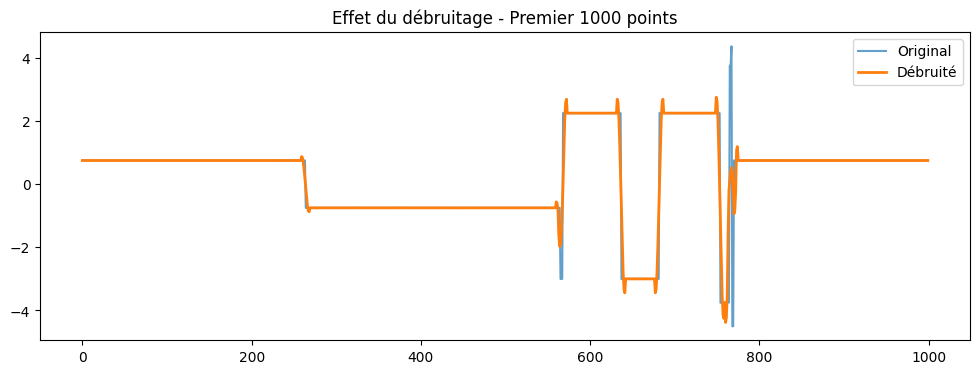

In [ ]:
# Ajouter ces imports
from scipy.signal import savgol_filter
import numpy as np
import matplotlib.pyplot as plt

test_signal = battery4_filled.iloc[25]['Courant']
denoised_signal = savgol_filter(test_signal, 11, 3)

plt.figure(figsize=(12, 4))
plt.plot(test_signal[:1000], label='Original', alpha=0.7)
plt.plot(denoised_signal[:1000], label='Débruité', linewidth=2)
plt.legend()
plt.title('Effet du débruitage - Premier 1000 points')
plt.show()

In [ ]:
# Appliquer le débruitage
'''
battery1_denoised = denoise_savgol_fixed(battery1_filled)
battery2_denoised = denoise_savgol_fixed(battery2_filled)
battery3_denoised = denoise_savgol_fixed(battery3_filled)
battery4_denoised = denoise_savgol_fixed(battery4_filled)

print("Debruitage terminé!")
print("Shape battery1_denoised:", battery1_denoised.shape)'''

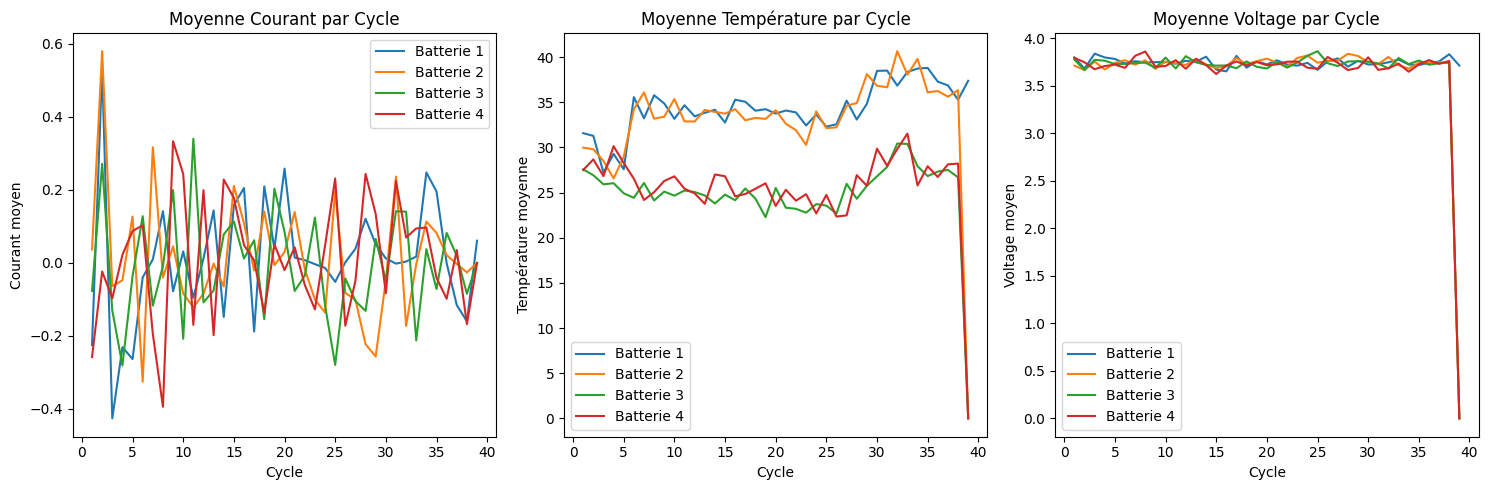

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Listes pour stocker les moyennes par batterie et par variable
means_courant = [[], [], [], []]
means_temperature = [[], [], [], []]
means_voltage = [[], [], [], []]

list_batteries = [battery1_filled, battery2_filled, battery3_filled, battery4_filled]

for i, battery_df in enumerate(list_batteries):
    for cycle in range(len(battery_df)):  # 39 cycles
        means_courant[i].append(np.mean(battery_df['Courant'].iloc[cycle]))
        means_temperature[i].append(np.mean(battery_df['Temperature'].iloc[cycle]))
        means_voltage[i].append(np.mean(battery_df['Voltage'].iloc[cycle]))

cycles = range(1, len(battery1_filled) + 1)  # 1 à 39

plt.figure(figsize=(15, 5))

# Courant
plt.subplot(1, 3, 1)
for i in range(4):
    plt.plot(cycles, means_courant[i], label=f'Batterie {i+1}')
plt.title('Moyenne Courant par Cycle')
plt.xlabel('Cycle')
plt.ylabel('Courant moyen')
plt.legend()

# Temperature
plt.subplot(1, 3, 2)
for i in range(4):
    plt.plot(cycles, means_temperature[i], label=f'Batterie {i+1}')
plt.title('Moyenne Température par Cycle')
plt.xlabel('Cycle')
plt.ylabel('Température moyenne')
plt.legend()

# Voltage
plt.subplot(1, 3, 3)
for i in range(4):
    plt.plot(cycles, means_voltage[i], label=f'Batterie {i+1}')
plt.title('Moyenne Voltage par Cycle')
plt.xlabel('Cycle')
plt.ylabel('Voltage moyen')
plt.legend()

plt.tight_layout()
plt.show()

In [35]:
print("===== temperature=====\n")
print(battery1_filled['Temperature'].iloc[38])
print(battery2_filled['Temperature'].iloc[38])
print(battery3_filled['Temperature'].iloc[38])
print(battery4_filled['Temperature'].iloc[38])

print("\n===== voltage=====\n")
print(battery1_filled['Voltage'].iloc[38])
print(battery2_filled['Voltage'].iloc[38])
print(battery3_filled['Voltage'].iloc[38])
print(battery4_filled['Voltage'].iloc[38])

===== temperature=====

[36.4208  36.4208  36.4208  ... 38.32224 38.32224 38.32224]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]

===== voltage=====

[4.005 4.006 4.006 ... 3.407 3.406 3.405]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]


In [36]:
#fonction pour supprimer les lignes qui contient que de Zeros

def remove_zero_rows(battery_df, variables_list, battery_index):
    zero_rows = battery_df
    for var in variables_list:
        zero_rows = zero_rows[zero_rows[var].apply(lambda x: not np.all(x == 0))]

    removed_rows = battery_df.index.difference(zero_rows.index)
    if len(removed_rows) > 0:
        for row in removed_rows:
            print(f"La ligne {row + 1} de la batterie {battery_index} est supprimée.")

    return zero_rows


# Delete rows that contain only zeros


In [37]:
variables_list = ['Courant', 'Voltage', 'Temperature']

battery1_cleaned = remove_zero_rows(battery1_filled, variables_list, 1)
battery2_cleaned = remove_zero_rows(battery2_filled, variables_list, 2)
battery3_cleaned = remove_zero_rows(battery3_filled, variables_list, 3)
battery4_cleaned = remove_zero_rows(battery4_filled, variables_list, 4)

print(battery1_cleaned.shape)
print(battery2_cleaned.shape)
print(battery3_cleaned.shape)
print(battery4_cleaned.shape)

La ligne 39 de la batterie 2 est supprimée.
La ligne 39 de la batterie 3 est supprimée.
La ligne 39 de la batterie 4 est supprimée.
(39, 5)
(38, 5)
(38, 5)
(38, 5)


# Verification

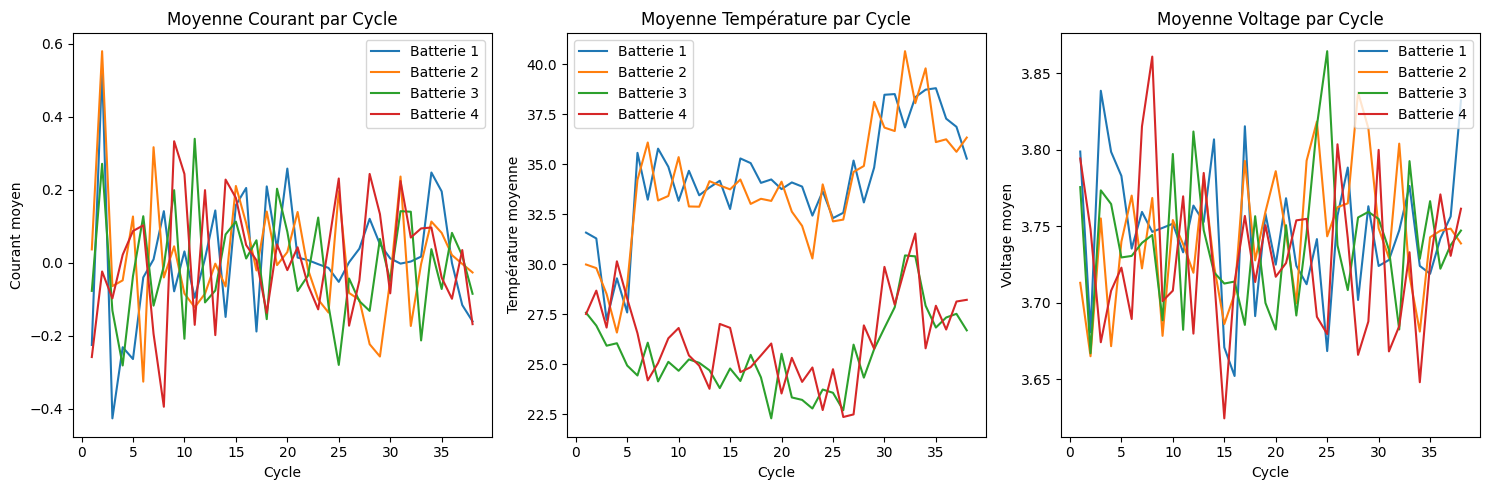

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Listes pour stocker les moyennes par batterie et par variable
means_courant = [[], [], [], []]
means_temperature = [[], [], [], []]
means_voltage = [[], [], [], []]
battery1_cleaned1 = battery1_cleaned.iloc[:-1].reset_index(drop=True)

list_batteries = [battery1_cleaned1, battery2_cleaned, battery3_cleaned, battery4_cleaned]

for i, battery_df in enumerate(list_batteries):
    for cycle in range(len(battery_df)):  # 39 cycles
        means_courant[i].append(np.mean(battery_df['Courant'].iloc[cycle]))
        means_temperature[i].append(np.mean(battery_df['Temperature'].iloc[cycle]))
        means_voltage[i].append(np.mean(battery_df['Voltage'].iloc[cycle]))

cycles = range(1, len(battery1_cleaned1) + 1)  # 1 à 39

plt.figure(figsize=(15, 5))

# Courant
plt.subplot(1, 3, 1)
for i in range(4):
    plt.plot(cycles, means_courant[i], label=f'Batterie {i+1}')
plt.title('Moyenne Courant par Cycle')
plt.xlabel('Cycle')
plt.ylabel('Courant moyen')
plt.legend()

# Temperature
plt.subplot(1, 3, 2)
for i in range(4):
    plt.plot(cycles, means_temperature[i], label=f'Batterie {i+1}')
plt.title('Moyenne Température par Cycle')
plt.xlabel('Cycle')
plt.ylabel('Température moyenne')
plt.legend()

# Voltage
plt.subplot(1, 3, 3)
for i in range(4):
    plt.plot(cycles, means_voltage[i], label=f'Batterie {i+1}')
plt.title('Moyenne Voltage par Cycle')
plt.xlabel('Cycle')
plt.ylabel('Voltage moyen')
plt.legend()

plt.tight_layout()
plt.show()

In [38]:
list_batteries = [battery1_cleaned, battery2_cleaned, battery3_cleaned, battery4_cleaned]


# Standardize the temperature


In [19]:
from sklearn.preprocessing import StandardScaler , MinMaxScaler
import numpy as np

col_name = 'Temperature'

for bat in list_batteries:
    if col_name in bat.columns:
        temp_matrix = np.stack(bat[col_name].values)
        scaler = StandardScaler()
        temp_scaled = scaler.fit_transform(temp_matrix)
        bat[col_name] = list(temp_scaled)



# Extract features

In [39]:
def extract_features(df):
    features = pd.DataFrame()

    for col in ['Courant', 'Temperature', 'Voltage', 'Time']:
        features[f'{col}_mean'] = df[col].apply(lambda x: np.mean(x))
        features[f'{col}_std'] = df[col].apply(lambda x: np.std(x))
        features[f'{col}_min'] = df[col].apply(lambda x: np.min(x))
        features[f'{col}_max'] = df[col].apply(lambda x: np.max(x))
        features[f'{col}_median'] = df[col].apply(lambda x: np.median(x))

    features['Y'] = df['Y'].apply(lambda x: float(x[0]) if isinstance(x, (list, np.ndarray)) and len(x) > 0 else float(x))

    return features



battery1_features = extract_features(battery1_cleaned)
battery2_features = extract_features(battery2_cleaned)
battery3_features = extract_features(battery3_cleaned)
battery4_features = extract_features(battery4_cleaned)

print(battery1_features.shape)
print(battery2_features.shape)
print(battery3_features.shape)
print(battery4_features.shape)


(39, 21)
(38, 21)
(38, 21)
(38, 21)


In [24]:
battery1_features.head()

,Courant_mean,Courant_std,Courant_min,Courant_max,Courant_median,Temperature_mean,Temperature_std,Temperature_min,Temperature_max,Temperature_median,...,Voltage_std,Voltage_min,Voltage_max,Voltage_median,Time_mean,Time_std,Time_min,Time_max,Time_median,Y
0,-0.224846,2.800636,-4.508,4.504,-0.750,-0.847047,0.976282,-2.161751,1.411458,-1.006798,...,0.288470,3.200,4.200,3.8570,146.450568,87.653026,0.03,300.0,144.040,2.042708
1,0.533235,2.572985,-4.509,4.384,1.500,-1.007039,0.522436,-2.271640,0.003750,-0.932795,...,0.305726,3.093,4.217,3.6150,139.142392,86.733356,0.01,300.0,132.040,1.981562
2,-0.425922,2.030758,-3.753,3.753,-1.499,-2.335220,0.339776,-2.826885,-0.742085,-2.396694,...,0.249101,3.235,4.223,3.9090,144.823336,88.111380,0.01,300.0,141.540,1.910397
3,-0.230990,2.163244,-4.501,3.753,-0.750,-1.647251,0.457821,-2.352093,-0.458345,-1.702760,...,0.280936,3.200,4.200,3.8835,143.768270,87.192238,0.04,300.0,142.040,1.854692
4,-0.263388,2.064613,-4.392,4.505,-0.750,-2.206123,0.537284,-3.614783,-0.960457,-2.251580,...,0.273463,3.186,4.277,3.8380,134.038944,87.004124,0.01,300.0,128.035,1.762266


# Keep only the most correlated variables
but these variables are obtained when the data are combined


In [40]:
selected_cols = ['Courant_std', 'Temperature_std', 'Temperature_min', 'Time_min', 'Y']

# Filtrer les colonnes
b1 = battery1_features[selected_cols].copy()
b2 = battery2_features[selected_cols].copy()
b3 = battery3_features[selected_cols].copy()
b4 = battery4_features[selected_cols].copy()



print(b1.shape)
print(b2.shape)
print(b3.shape)
print(b4.shape)
print(b1.columns)

(39, 5)
(38, 5)
(38, 5)
(38, 5)
Index(['Courant_std', 'Temperature_std', 'Temperature_min', 'Time_min', 'Y'], dtype='object')


# LOBO (Leave One Battery Out)

In [41]:
from sklearn.linear_model import BayesianRidge, LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

#fonction permettant de choisir le classifier

def train_and_evaluate(X_train, y_train, X_test, y_test, model_name="GradientBoosting"):
    if model_name == "GradientBoosting":
        model = GradientBoostingRegressor()
    elif model_name == "BayesianRidge":
        model = BayesianRidge()
    elif model_name == "RandomForest":
        model = RandomForestRegressor()
    elif model_name == "XGBoost":
        model = XGBRegressor()
    elif model_name == "LinearRegression":
        model = LinearRegression()
    else:
        raise NotImplementedError("Modèle non pris en charge.")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    return mse, r2, mape , y_pred

In [42]:
#LOBO
# Dictionnaire des batteries
batteries = {"B1" : b1 ,
             "B2" : b2 ,
             "B3" : b3 ,
             "B4" : b4}

results = []
chosen_model = "BayesianRidge"

for battery in batteries.keys():
  print(f"===== Iteration : {battery} =====")
  test_battery = batteries[battery]
  y_test = test_battery['Y']
  X_test = test_battery.drop(columns = 'Y')

  train_batteries = [k for k in batteries.keys() if k != battery]
  train_df = pd.concat([v for k, v in batteries.items() if k != battery])
  y_train = train_df['Y']
  X_train = train_df.drop(columns = 'Y')
  mse, r2, mape , y_pred = train_and_evaluate(X_train, y_train, X_test, y_test, model_name="BayesianRidge")
  results.append({
      "Test_Battery" : battery,
      "MSE" : mse * 100,
      "R2" : r2 * 100,
      "MAPE" : mape *100
  })

  results_df = pd.DataFrame(results)

print(results_df)


print("\n--- Résumé global ---")
print(f"Model utilisé : {chosen_model}")
print(f"Moyenne R² : {results_df['R2'].mean():.4f}")
print(f"Moyenne MAPE : {results_df['MAPE'].mean():.4f}")

===== Iteration : B1 =====
===== Iteration : B2 =====
===== Iteration : B3 =====
===== Iteration : B4 =====
  Test_Battery       MSE         R2       MAPE
0           B1  2.088926  81.720304   9.456625
1           B2  1.641700  82.907515   7.330922
2           B3  9.159614  -9.423993  22.917233
3           B4  6.493295   7.354845  13.864469

--- Résumé global ---
Model utilisé : BayesianRidge
Moyenne R² : 40.6397
Moyenne MAPE : 13.3923


# Normalize by **battery**


In [43]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd

def normalize_dataframe(df, method='minmax'):
    df_copy = df.copy()
    scaler = MinMaxScaler() if method == 'minmax' else StandardScaler()

    # Séparer X et Y
    X = df_copy.drop(columns='Y')
    y = df_copy['Y']

    # Normaliser X uniquement
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

    df_scaled = pd.concat([X_scaled, y], axis=1)
    return df_scaled


In [44]:
# MinMax
b1_minmax = normalize_dataframe(b1, method='minmax')
b2_minmax = normalize_dataframe(b2, method='minmax')
b3_minmax = normalize_dataframe(b3, method='minmax')
b4_minmax = normalize_dataframe(b4, method='minmax')

# Dictionnaire des batteries
batteries = {
    "B1": b1_minmax,
    "B2": b2_minmax,
    "B3": b3_minmax,
    "B4": b4_minmax
}

results = []
chosen_model = "BayesianRidge"

iteration = 1
for test_battery in batteries.keys():
    print(f"===== Iteration {iteration} =====")

    # Construire la liste des batteries d'entraînement
    train_batteries = [k for k in batteries.keys() if k != test_battery]
    print(f"Train = {' + '.join(train_batteries)}, Test = {test_battery}")

    test_df = batteries[test_battery]
    y_test = test_df['Y'].values
    X_test = test_df.drop(columns=['Y'])

    train_df = pd.concat([v for k, v in batteries.items() if k != test_battery])
    y_train = train_df['Y'].values
    X_train = train_df.drop(columns=['Y'])

    # Conversion explicite en float et remplissage NaN
    y_train = pd.Series(y_train).astype(float).fillna(pd.Series(y_train).astype(float).mean()).values
    y_test = pd.Series(y_test).astype(float).fillna(pd.Series(y_test).astype(float).mean()).values

    mse, r2, mape, y_pred = train_and_evaluate(X_train, y_train, X_test, y_test, model_name=chosen_model)

    results.append({
        "Test_Battery": test_battery,
        "MSE": mse,
        "R2": f"{r2*100:.2f}%",
        "MAPE": f"{mape*100:.2f}%"
    })

    iteration += 1
    print()

results_df = pd.DataFrame(results)
print(results_df)

print("\n--- Résumé global ---")
print(f"Model utilisé : {chosen_model}")
print(f"Moyenne MSE : {np.mean([float(r['MSE']) for r in results]):.6f}")
print(f"Moyenne R² : {np.mean([float(r['R2'].rstrip('%'))/100 for r in results])*100:.2f}%")
print(f"Moyenne MAPE : {np.mean([float(r['MAPE'].rstrip('%'))/100 for r in results])*100:.2f}%")

===== Iteration 1 =====
Train = B2 + B3 + B4, Test = B1

===== Iteration 2 =====
Train = B1 + B3 + B4, Test = B2

===== Iteration 3 =====
Train = B1 + B2 + B4, Test = B3

===== Iteration 4 =====
Train = B1 + B2 + B3, Test = B4

  Test_Battery       MSE      R2    MAPE
0           B1  0.027050  76.33%  12.41%
1           B2  0.020801  78.34%   8.39%
2           B3  0.019154  77.12%   9.60%
3           B4  0.038587  44.94%   9.99%

--- Résumé global ---
Model utilisé : BayesianRidge
Moyenne MSE : 0.026398
Moyenne R² : 69.18%
Moyenne MAPE : 10.10%



Corrélation avec Y pour Battery 1 :
Courant_std           0.859913
Voltage_min           0.646432
Temperature_std       0.619536
Time_mean             0.618689
Time_median           0.595941
Time_min              0.442105
Courant_min           0.386890
Voltage_mean          0.190710
Voltage_median        0.046328
Courant_median       -0.103536
Courant_mean         -0.187013
Time_std             -0.266399
Courant_max          -0.415428
Temperature_max      -0.441728
Voltage_std          -0.499120
Temperature_mean     -0.707703
Temperature_median   -0.709187
Voltage_max          -0.766649
Temperature_min      -0.768241
Time_max                   NaN
Name: Y, dtype: float64


/tmp/ipython-input-30-4016853433.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_y.values, y=corr_with_y.index, palette='coolwarm')


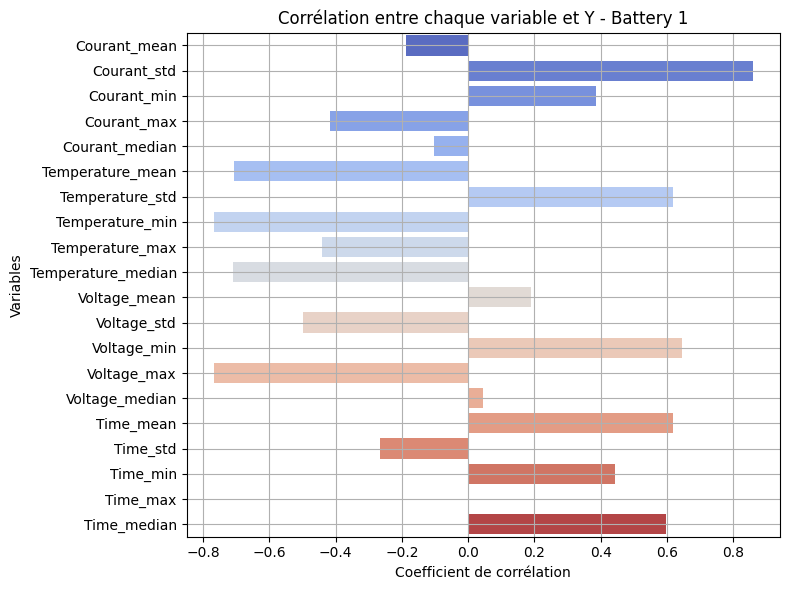


Corrélation avec Y pour Battery 2 :
Courant_std           0.884957
Time_min              0.534867
Temperature_std       0.521707
Time_mean             0.481316
Time_median           0.436678
Voltage_min           0.399229
Courant_mean          0.211958
Courant_min           0.071514
Courant_median       -0.085870
Voltage_median       -0.185999
Courant_max          -0.266929
Voltage_mean         -0.315407
Time_std             -0.371959
Voltage_std          -0.412771
Temperature_max      -0.585736
Temperature_mean     -0.712202
Temperature_median   -0.716763
Voltage_max          -0.769298
Temperature_min      -0.778839
Time_max                   NaN
Name: Y, dtype: float64


/tmp/ipython-input-30-4016853433.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_y.values, y=corr_with_y.index, palette='coolwarm')


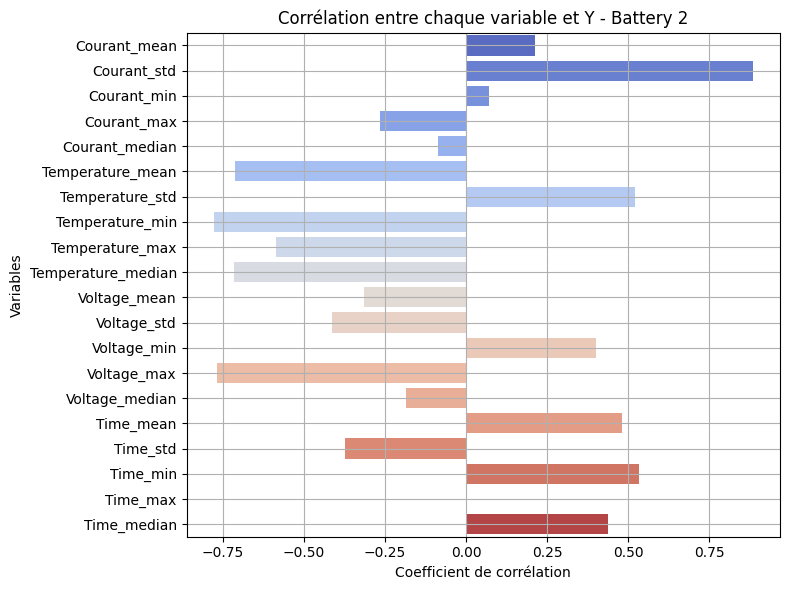


Corrélation avec Y pour Battery 3 :
Courant_std           0.918414
Temperature_std       0.700111
Voltage_min           0.597689
Time_min              0.359730
Time_mean             0.359611
Time_median           0.299047
Temperature_max       0.207823
Courant_median        0.164887
Courant_min           0.059288
Voltage_mean         -0.002651
Courant_mean         -0.043772
Courant_max          -0.044705
Voltage_median       -0.082098
Temperature_mean     -0.148524
Temperature_median   -0.173474
Temperature_min      -0.337790
Time_std             -0.442118
Voltage_std          -0.523570
Voltage_max          -0.606423
Time_max                   NaN
Name: Y, dtype: float64


/tmp/ipython-input-30-4016853433.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_y.values, y=corr_with_y.index, palette='coolwarm')


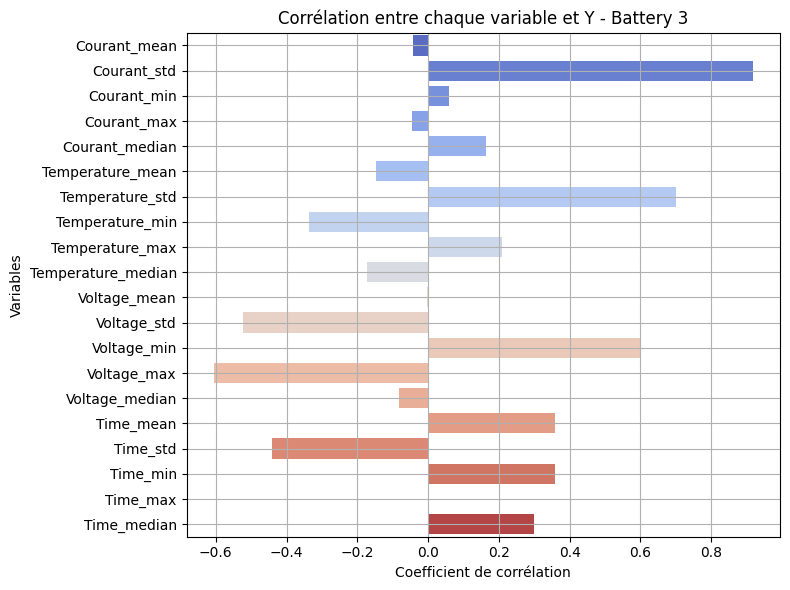


Corrélation avec Y pour Battery 4 :
Courant_std           0.828450
Voltage_min           0.560802
Temperature_std       0.516157
Time_mean             0.290769
Time_median           0.288149
Temperature_max       0.242566
Courant_min           0.162484
Time_min              0.127754
Voltage_mean          0.125792
Voltage_std           0.070667
Voltage_median        0.055178
Temperature_mean     -0.021259
Temperature_median   -0.042359
Courant_max          -0.051125
Courant_median       -0.064093
Courant_mean         -0.142559
Temperature_min      -0.238178
Time_std             -0.337653
Voltage_max          -0.629936
Time_max                   NaN
Name: Y, dtype: float64


/tmp/ipython-input-30-4016853433.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_y.values, y=corr_with_y.index, palette='coolwarm')


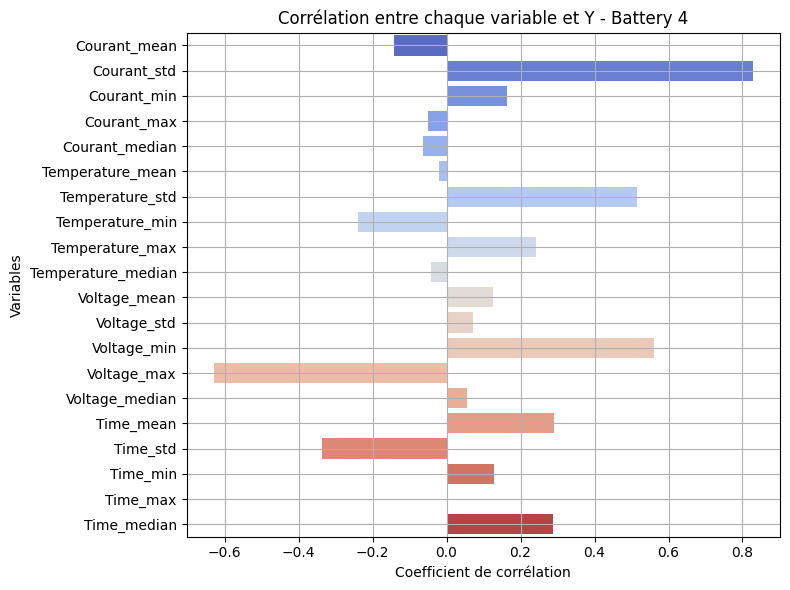

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_corr_with_y(battery_features, battery_name):
    if 'Y' not in battery_features.columns:
        print(f"Pas de colonne Y dans {battery_name}, ignoré.")
        return

    df_corr = battery_features.corr()
    corr_with_y = df_corr['Y'].drop('Y')

    print(f"\nCorrélation avec Y pour {battery_name} :")
    print(corr_with_y.sort_values(ascending=False))

    plt.figure(figsize=(8, max(4, len(corr_with_y)*0.3)))
    sns.barplot(x=corr_with_y.values, y=corr_with_y.index, palette='coolwarm')
    plt.title(f'Corrélation entre chaque variable et Y - {battery_name}')
    plt.xlabel('Coefficient de corrélation')
    plt.ylabel('Variables')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_corr_with_y(battery1_features.assign(Y=battery1_cleaned['Y']), "Battery 1")
plot_corr_with_y(battery2_features.assign(Y=battery2_cleaned['Y']), "Battery 2")
plot_corr_with_y(battery3_features.assign(Y=battery3_cleaned['Y']), "Battery 3")
plot_corr_with_y(battery4_features.assign(Y=battery4_cleaned['Y']), "Battery 4")

In [ ]:
def get_filtered_corr_vars(battery_features, battery_y, battery_name, threshold=0.4):
    df = battery_features.copy()
    df['Y'] = battery_y

    if 'Y' not in df.columns:
        print(f"Pas de colonne Y dans {battery_name}, ignoré.")
        return []

    corr = df.corr()
    corr_with_y = corr['Y'].drop('Y')
    filtered_corr = corr_with_y[corr_with_y.abs() >= threshold]

    if filtered_corr.empty:
        print(f"Aucune variable avec corrélation >= {threshold} pour {battery_name}")
        return []
    else:
        print(f"\n {battery_name} : {len(filtered_corr)} variables sélectionnées (|corr| ≥ {threshold})")
        for var, val in filtered_corr.items():
            print(f"  - {var}: {val:.3f}")
        return list(filtered_corr.index)


# Appels pour obtenir les noms des variables retenues
features_b1 = get_filtered_corr_vars(battery1_features, battery1_cleaned['Y'], "Battery 1")
features_b2 = get_filtered_corr_vars(battery2_features, battery2_cleaned['Y'], "Battery 2")
features_b3 = get_filtered_corr_vars(battery3_features, battery3_cleaned['Y'], "Battery 3")
features_b4 = get_filtered_corr_vars(battery4_features, battery4_cleaned['Y'], "Battery 4")


 Battery 1 : 12 variables sélectionnées (|corr| ≥ 0.4)
  - Courant_std: 0.860
  - Courant_max: -0.415
  - Temperature_mean: -0.708
  - Temperature_std: 0.694
  - Temperature_min: -0.783
  - Temperature_median: -0.711
  - Voltage_std: -0.499
  - Voltage_min: 0.646
  - Voltage_max: -0.767
  - Time_mean: 0.619
  - Time_min: 0.442
  - Time_median: 0.596

 Battery 2 : 11 variables sélectionnées (|corr| ≥ 0.4)
  - Courant_std: 0.885
  - Temperature_mean: -0.713
  - Temperature_std: 0.541
  - Temperature_min: -0.800
  - Temperature_max: -0.539
  - Temperature_median: -0.718
  - Voltage_std: -0.413
  - Voltage_max: -0.769
  - Time_mean: 0.481
  - Time_min: 0.535
  - Time_median: 0.437

 Battery 3 : 6 variables sélectionnées (|corr| ≥ 0.4)
  - Courant_std: 0.918
  - Temperature_std: 0.695
  - Voltage_std: -0.524
  - Voltage_min: 0.598
  - Voltage_max: -0.606
  - Time_std: -0.442

 Battery 4 : 4 variables sélectionnées (|corr| ≥ 0.4)
  - Courant_std: 0.828
  - Temperature_std: 0.559
  - Voltage

In [ ]:
# Union des variables sélectionnées
selected_features = set(features_b1) | set(features_b2) | set(features_b3) | set(features_b4)
print(f"\nUnion finale des variables sélectionnées : {selected_features}")

# Fonction d'alignement
def align_features(df_features, df_y, selected_features):
    df = df_features.copy()
    df['Y'] = df_y

    for feature in selected_features:
        if feature not in df.columns:
            df[feature] = np.nan

    df = df[list(selected_features) + ['Y']]
    df.fillna(df.mean(), inplace=True)
    return df

# Création des DataFrames alignés
battery1_final = align_features(battery1_features, battery1_cleaned['Y'], selected_features)
battery2_final = align_features(battery2_features, battery2_cleaned['Y'], selected_features)
battery3_final = align_features(battery3_features, battery3_cleaned['Y'], selected_features)
battery4_final = align_features(battery4_features, battery4_cleaned['Y'], selected_features)


Union finale des variables sélectionnées : {'Voltage_max', 'Temperature_mean', 'Voltage_std', 'Courant_max', 'Voltage_min', 'Temperature_median', 'Courant_std', 'Time_min', 'Time_mean', 'Time_median', 'Temperature_max', 'Time_std', 'Temperature_min', 'Temperature_std'}


In [45]:
sel1 = ['Courant_std' , 'Temperature_std' , 'Voltage_min' , 'Voltage_max' ,'Voltage_std' , 'Time_std',
        'Temperature_mean',  'Temperature_min' ,'Temperature_max','Temperature_median','Time_mean','Time_min',
        'Time_median','Courant_max' ,     'Y']



# Filtrer les colonnes
b1 = battery1_features[sel1].copy()
b2 = battery2_features[sel1].copy()
b3 = battery3_features[sel1].copy()
b4 = battery4_features[sel1].copy()

print(b1.shape)
print(b2.shape)
print(b3.shape)
print(b4.shape)
print(b1.columns)



(39, 15)
(38, 15)
(38, 15)
(38, 15)
Index(['Courant_std', 'Temperature_std', 'Voltage_min', 'Voltage_max',
       'Voltage_std', 'Time_std', 'Temperature_mean', 'Temperature_min',
       'Temperature_max', 'Temperature_median', 'Time_mean', 'Time_min',
       'Time_median', 'Courant_max', 'Y'],
      dtype='object')


In [46]:
# MinMax

b1_minmax = normalize_dataframe(b1, method='minmax')
b2_minmax = normalize_dataframe(b2, method='minmax')
b3_minmax = normalize_dataframe(b3, method='minmax')
b4_minmax = normalize_dataframe(b4, method='minmax')


# Dictionnaire des batteries déjà MinMax-scalées localement
batteries = {
    "B1": b1_minmax,
    "B2": b2_minmax,
    "B3": b3_minmax,
    "B4":b4_minmax
}

results = []
#XGBoost , GradientBoosting , RandomForest , BayesianRidge , LinearRegression
chosen_model = "BayesianRidge"
for test_battery in batteries.keys():
    test_df = batteries[test_battery]
    y_test = test_df['Y'].values
    X_test = test_df.drop(columns=['Y'])

    train_df = pd.concat([v for k, v in batteries.items() if k != test_battery])
    y_train = train_df['Y'].values
    X_train = train_df.drop(columns=['Y'])

    # Conversion explicite en float et remplissage NaN
    y_train = pd.Series(y_train).astype(float).fillna(pd.Series(y_train).astype(float).mean()).values
    y_test = pd.Series(y_test).astype(float).fillna(pd.Series(y_test).astype(float).mean()).values

    mse, r2, mape , y_pred = train_and_evaluate(X_train, y_train, X_test, y_test, model_name=chosen_model)

    results.append({
        "Test_Battery": test_battery,
        "MSE": mse,
        "R2": r2,
        "MAPE": mape
    })

results_df = pd.DataFrame(results)
print(results_df)

print("\n--- Résumé global ---")
print(f"Model utilisé : {chosen_model}")
print(f"Moyenne R² : {results_df['R2'].mean():.4f}")
print(f"Moyenne MAPE : {results_df['MAPE'].mean():.4f}")
print(f"Moyenne MSE : {results_df['MSE'].mean():.4f}")


  Test_Battery       MSE        R2      MAPE
0           B1  0.019050  0.833300  0.108045
1           B2  0.007262  0.924395  0.045027
2           B3  0.009724  0.883831  0.061145
3           B4  0.047503  0.322230  0.110445

--- Résumé global ---
Model utilisé : BayesianRidge
Moyenne R² : 0.7409
Moyenne MAPE : 0.0812
Moyenne MSE : 0.0209


# Interpretation: SHAP




In [ ]:
!pip install shap lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=35636e1cc49dff450d5b26b45469afeedbd9b0cbc8ad5b88ec90e0f0817f73f0
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


## We will apply SHAP twice, for the best result (B2), and the worst result (B4)






R2 batterie 2 (test): 0.9244
R2 batterie 4 (test): 0.3222

TOP 10 FEATURES BATTERIE 2 :
1. Courant_std     : 0.2441
5. Voltage_std     : 0.0795
8. Temperature_min : 0.0609
9. Temperature_max : 0.0608
13. Time_median     : 0.0511
3. Voltage_min     : 0.0460
11. Time_mean       : 0.0388
2. Temperature_std : 0.0338
10. Temperature_median : 0.0264
7. Temperature_mean : 0.0167


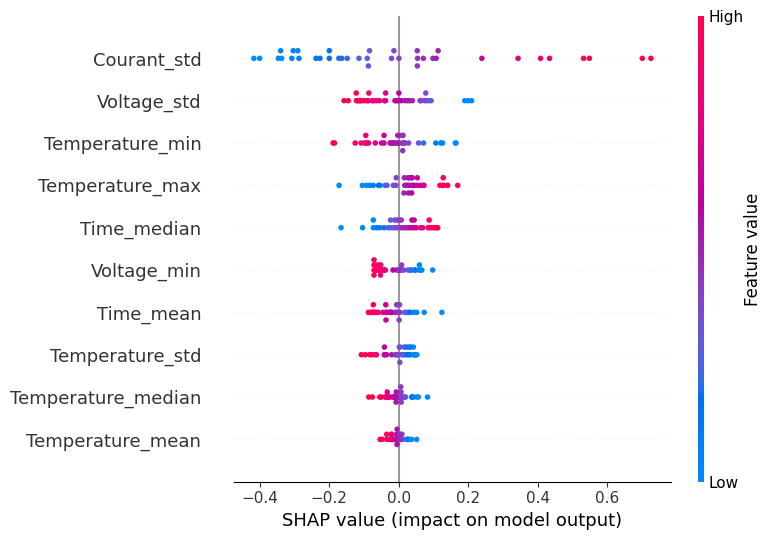

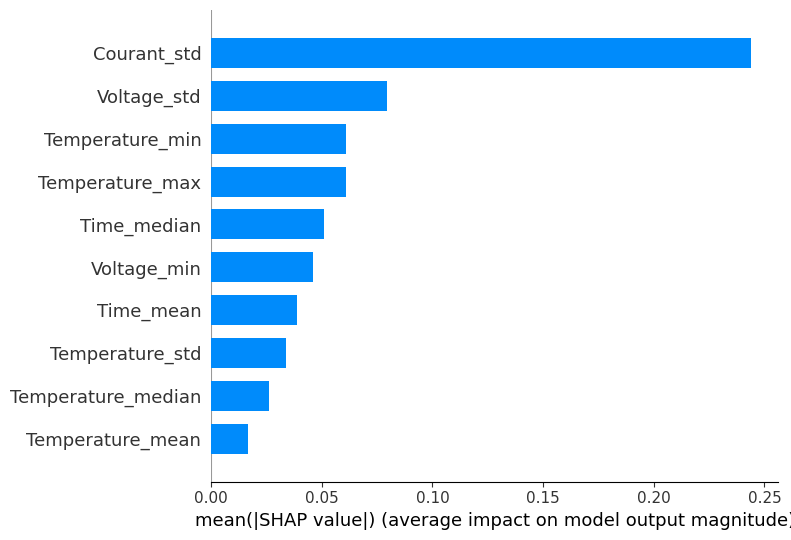

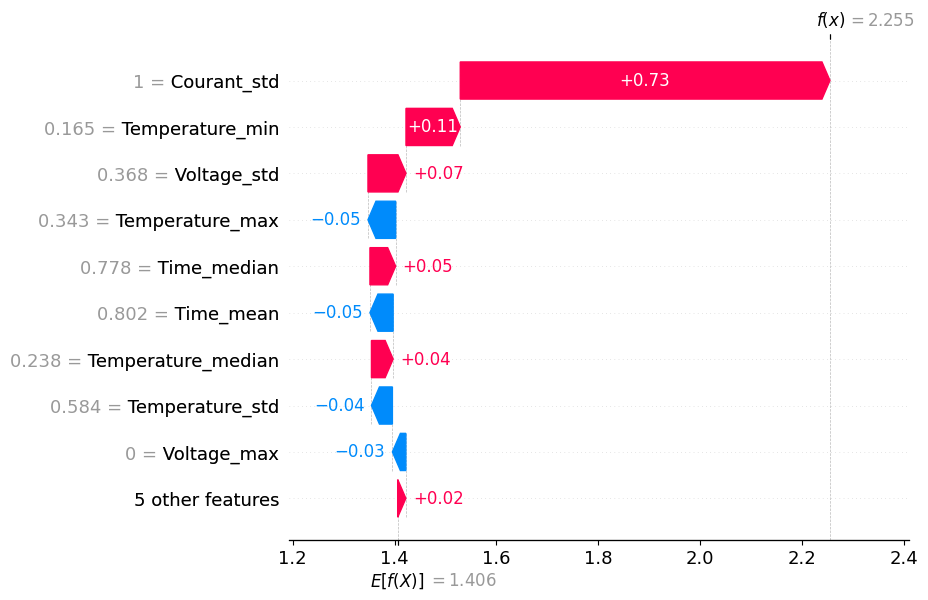


TOP 10 FEATURES BATTERIE 4 :
1. Courant_std     : 0.1863
5. Voltage_std     : 0.0693
8. Temperature_min : 0.0529
9. Temperature_max : 0.0304
7. Temperature_mean : 0.0283
6. Time_std        : 0.0184
14. Courant_max     : 0.0161
4. Voltage_max     : 0.0149
3. Voltage_min     : 0.0125
13. Time_median     : 0.0113


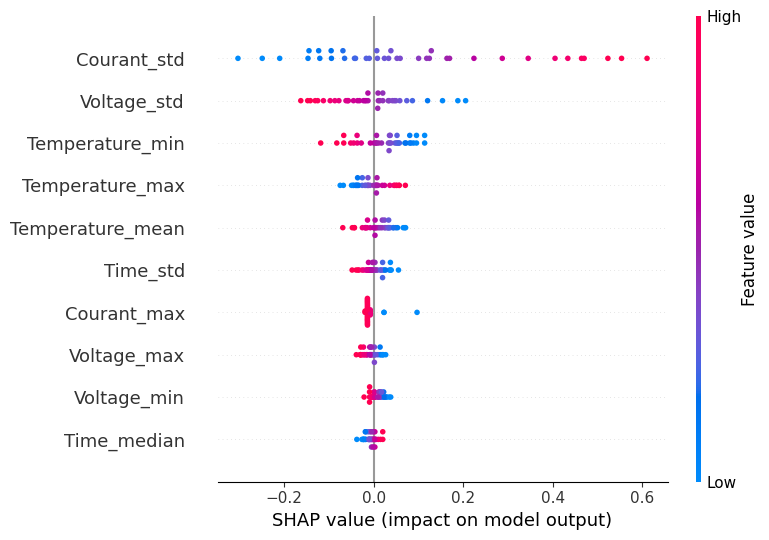

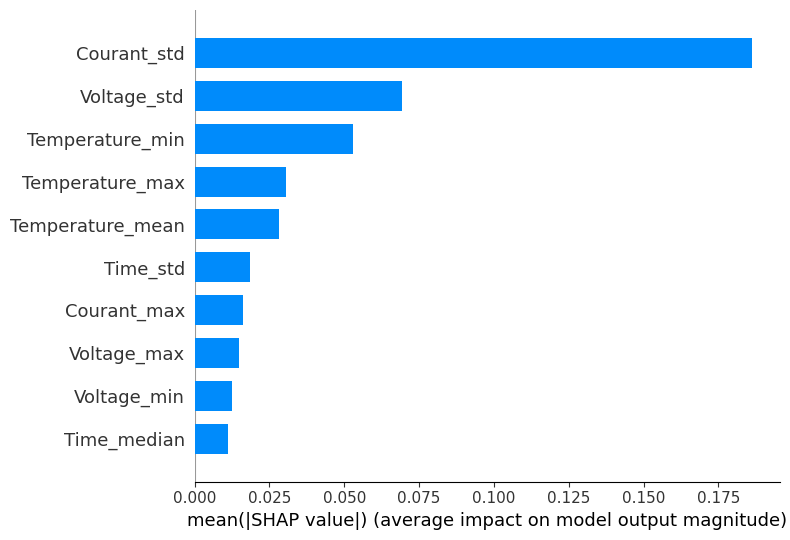

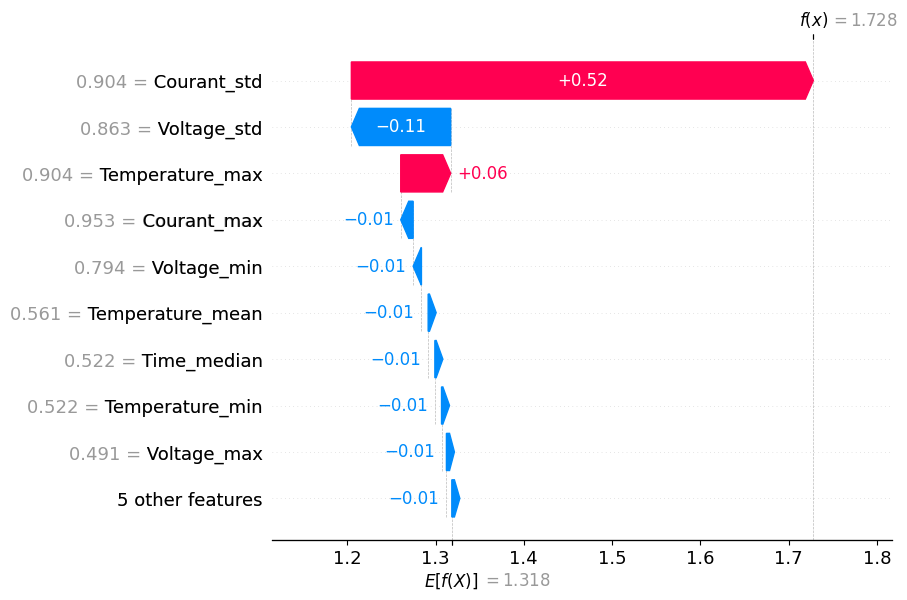

In [47]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split

#data
b1_minmax = normalize_dataframe(b1, method='minmax')
b2_minmax = normalize_dataframe(b2, method='minmax')
b3_minmax = normalize_dataframe(b3, method='minmax')
b4_minmax = normalize_dataframe(b4, method='minmax')



# train (tout sauf B2)
train_dfs_b2 = [b1_minmax, b3_minmax, b4_minmax]


train_df_b2 = pd.concat(train_dfs_b2, ignore_index=True)
X_train_b2 = train_df_b2.drop(columns='Y')
y_train_b2 = train_df_b2['Y']

# train (tout sauf B4)
train_dfs_b4 = [b1_minmax, b2_minmax, b3_minmax]
train_df_b4 = pd.concat(train_dfs_b4, ignore_index=True)
X_train_b4 = train_df_b4.drop(columns='Y')
y_train_b4 = train_df_b4['Y']





# data test B2
X_test_b2 = b2_minmax.drop(columns='Y')
y_test_b2 = b2_minmax['Y']

# Data test B4
X_test_b4 = b4_minmax.drop(columns='Y')
y_test_b4 = b4_minmax['Y']




# M1
model_b2 = BayesianRidge()
model_b2.fit(X_train_b2, y_train_b2)

# P1
y_pred_b2 = model_b2.predict(X_test_b2)
r2_b2 = r2_score(y_test_b2, y_pred_b2)
print(f"R2 batterie 2 (test): {r2_b2:.4f}")

# M2
model_b4 = BayesianRidge()
model_b4.fit(X_train_b4, y_train_b4)

# P2
y_pred_b4 = model_b4.predict(X_test_b4)
r2_b4 = r2_score(y_test_b4, y_pred_b4)
print(f"R2 batterie 4 (test): {r2_b4:.4f}")

# ================ SHAP pour B2======================

explainer_b2 = shap.Explainer(model_b2, X_train_b2)
shap_values_b2 = explainer_b2(X_test_b2)

mean_abs_shap_b2 = np.abs(shap_values_b2.values).mean(axis=0)
feature_importance_b2 = pd.DataFrame({
    'Feature': X_test_b2.columns,
    'MeanAbsSHAP': mean_abs_shap_b2
}).sort_values(by='MeanAbsSHAP', ascending=False)

print("\nTOP 10 FEATURES BATTERIE 2 :")
for i, row in feature_importance_b2.head(10).iterrows():
    print(f"{i+1}. {row['Feature']:<15} : {row['MeanAbsSHAP']:.4f}")

# Plots SHAP batterie 2
shap.summary_plot(shap_values_b2, X_test_b2, max_display=10)
shap.summary_plot(shap_values_b2, X_test_b2, plot_type='bar', max_display=10)
shap.plots.waterfall(shap_values_b2[0])  # 1ere

# ================ SHAP pour B4======================

explainer_b4 = shap.Explainer(model_b4, X_train_b4)
shap_values_b4 = explainer_b4(X_test_b4)

mean_abs_shap_b4 = np.abs(shap_values_b4.values).mean(axis=0)
feature_importance_b4 = pd.DataFrame({
    'Feature': X_test_b4.columns,
    'MeanAbsSHAP': mean_abs_shap_b4
}).sort_values(by='MeanAbsSHAP', ascending=False)

print("\nTOP 10 FEATURES BATTERIE 4 :")
for i, row in feature_importance_b4.head(10).iterrows():
    print(f"{i+1}. {row['Feature']:<15} : {row['MeanAbsSHAP']:.4f}")

# Plots SHAP batterie 4
shap.summary_plot(shap_values_b4, X_test_b4, max_display=10)
shap.summary_plot(shap_values_b4, X_test_b4, plot_type='bar', max_display=10)
shap.plots.waterfall(shap_values_b4[0])  # Première instance


In [ ]:
print("=== Courant_max normalisé ===")
print(f"B1: {b1_minmax['Courant_max'].mean():.3f}")
print(f"B2: {b2_minmax['Courant_max'].mean():.3f}")
print(f"B3: {b3_minmax['Courant_max'].mean():.3f}")
print(f"B4: {b4_minmax['Courant_max'].mean():.3f}")

print("\n=== Voltage_max normalisé ===")
print(f"B1: {b1_minmax['Voltage_max'].mean():.3f}")
print(f"B2: {b2_minmax['Voltage_max'].mean():.3f}")
print(f"B3: {b3_minmax['Voltage_max'].mean():.3f}")
print(f"B4: {b4_minmax['Voltage_max'].mean():.3f}")

=== Courant_max normalisé ===
B1: 0.838
B2: 0.804
B3: 0.835
B4: 0.905

=== Voltage_max normalisé ===
B1: 0.449
B2: 0.405
B3: 0.352
B4: 0.510


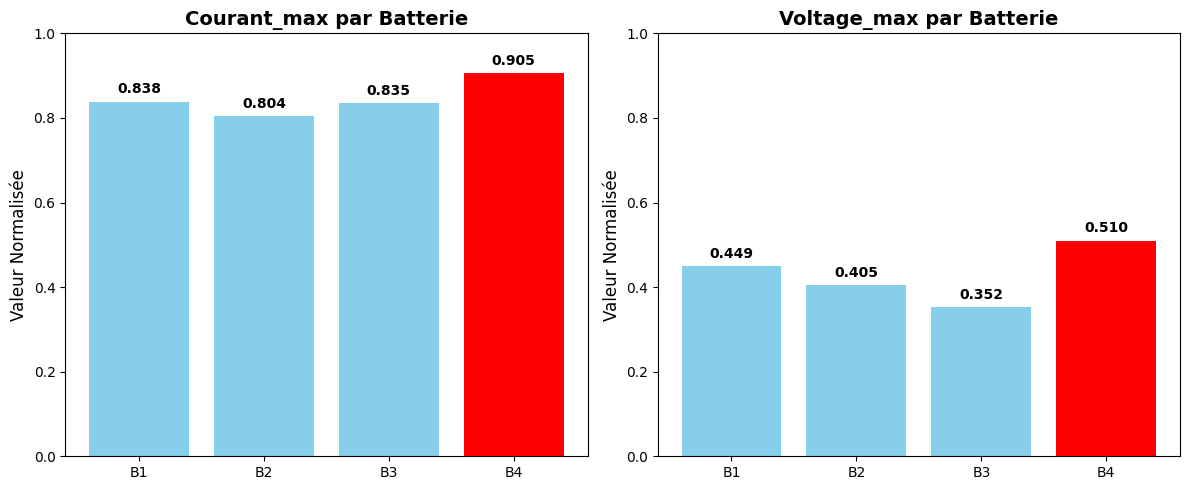

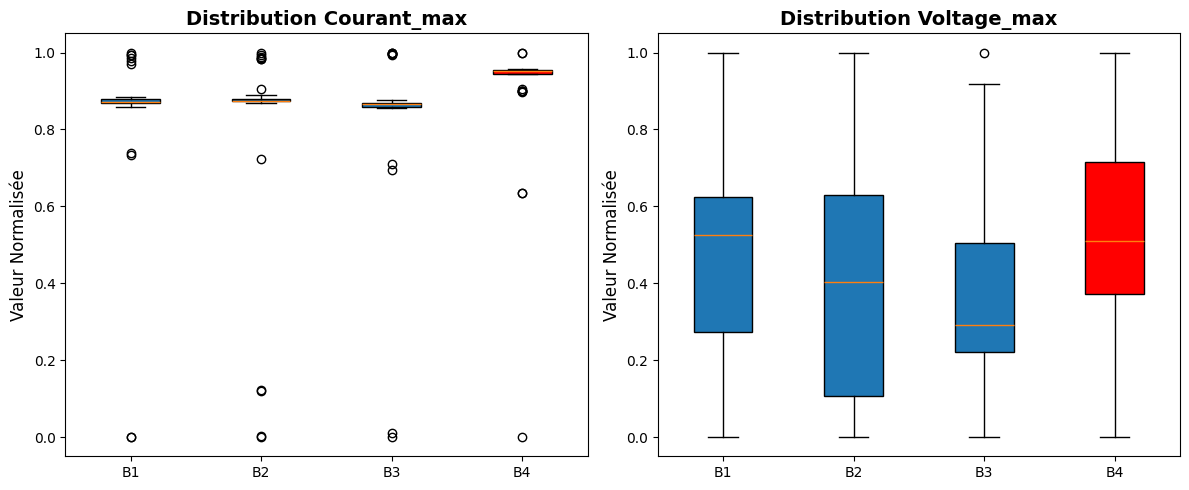

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# === GRAPHIQUE EN BARRES ===
plt.figure(figsize=(12, 5))

# Données pour les graphiques
batteries = ['B1', 'B2', 'B3', 'B4']
courant_max_values = [
    b1_minmax['Courant_max'].mean(),
    b2_minmax['Courant_max'].mean(),
    b3_minmax['Courant_max'].mean(),
    b4_minmax['Courant_max'].mean()
]
voltage_max_values = [
    b1_minmax['Voltage_max'].mean(),
    b2_minmax['Voltage_max'].mean(),
    b3_minmax['Voltage_max'].mean(),
    b4_minmax['Voltage_max'].mean()
]

# Subplot 1: Courant_max
plt.subplot(1, 2, 1)
bars1 = plt.bar(batteries, courant_max_values, color=['skyblue', 'skyblue', 'skyblue', 'red'])
plt.title('Courant_max par Batterie', fontsize=14, fontweight='bold')
plt.ylabel('Valeur Normalisée', fontsize=12)
plt.ylim(0, 1)
for i, v in enumerate(courant_max_values):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Subplot 2: Voltage_max
plt.subplot(1, 2, 2)
bars2 = plt.bar(batteries, voltage_max_values, color=['skyblue', 'skyblue', 'skyblue', 'red'])
plt.title('Voltage_max par Batterie', fontsize=14, fontweight='bold')
plt.ylabel('Valeur Normalisée', fontsize=12)
plt.ylim(0, 1)
for i, v in enumerate(voltage_max_values):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# === BOXPLOT
plt.figure(figsize=(12, 5))

# Préparation des données pour boxplot
courant_data = [b1_minmax['Courant_max'], b2_minmax['Courant_max'],
                b3_minmax['Courant_max'], b4_minmax['Courant_max']]
voltage_data = [b1_minmax['Voltage_max'], b2_minmax['Voltage_max'],
                b3_minmax['Voltage_max'], b4_minmax['Voltage_max']]

# Subplot 1: Courant_max boxplot
plt.subplot(1, 2, 1)
box1 = plt.boxplot(courant_data, labels=batteries, patch_artist=True)
box1['boxes'][3].set_facecolor('red')  # B4 en rouge
plt.title('Distribution Courant_max', fontsize=14, fontweight='bold')
plt.ylabel('Valeur Normalisée', fontsize=12)

# Subplot 2: Voltage_max boxplot
plt.subplot(1, 2, 2)
box2 = plt.boxplot(voltage_data, labels=batteries, patch_artist=True)
box2['boxes'][3].set_facecolor('red')  # B4 en rouge
plt.title('Distribution Voltage_max', fontsize=14, fontweight='bold')
plt.ylabel('Valeur Normalisée', fontsize=12)

plt.tight_layout()
plt.show()

# Real values VS Predicted values

===== Iteration 1 =====
Train = B2 + B3 + B4, Test = B1

===== Iteration 2 =====
Train = B1 + B3 + B4, Test = B2

===== Iteration 3 =====
Train = B1 + B2 + B4, Test = B3

===== Iteration 4 =====
Train = B1 + B2 + B3, Test = B4



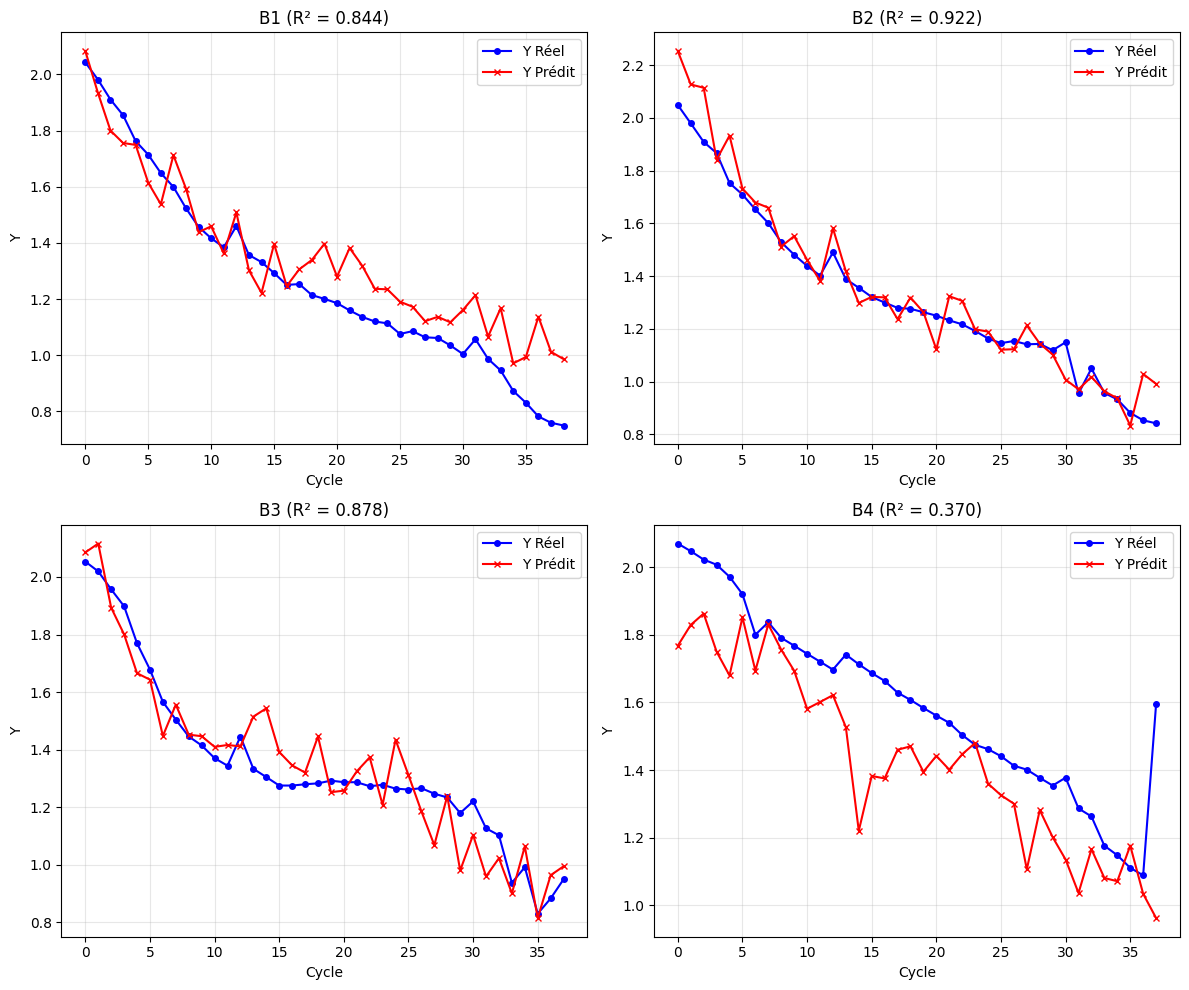

  Test_Battery       MSE      R2    MAPE
0           B1  0.017868  84.36%  10.46%
1           B2  0.007450  92.24%   4.69%
2           B3  0.010252  87.75%   6.44%
3           B4  0.044164  36.99%  10.47%

--- Résumé global ---
Model utilisé : LinearRegression
Moyenne MSE : 0.019934
Moyenne R² : 75.33%
Moyenne MAPE : 8.02%


In [48]:
import matplotlib.pyplot as plt

# MinMax
b1_minmax = normalize_dataframe(b1, method='minmax')
b2_minmax = normalize_dataframe(b2, method='minmax')
b3_minmax = normalize_dataframe(b3, method='minmax')
b4_minmax = normalize_dataframe(b4, method='minmax')

batteries = {
    "B1": b1_minmax,
    "B2": b2_minmax,
    "B3": b3_minmax,
    "B4": b4_minmax
}

results = []
#XGBoost , GradientBoosting , RandomForest , BayesianRidge , LinearRegression

chosen_model = "LinearRegression"
all_predictions = {}

iteration = 1
for test_battery in batteries.keys():
    print(f"===== Iteration {iteration} =====")

    train_batteries = [k for k in batteries.keys() if k != test_battery]
    print(f"Train = {' + '.join(train_batteries)}, Test = {test_battery}")

    test_df = batteries[test_battery]
    y_test = test_df['Y'].values
    X_test = test_df.drop(columns=['Y'])

    train_df = pd.concat([v for k, v in batteries.items() if k != test_battery])
    y_train = train_df['Y'].values
    X_train = train_df.drop(columns=['Y'])

    y_train = pd.Series(y_train).astype(float).fillna(pd.Series(y_train).astype(float).mean()).values
    y_test = pd.Series(y_test).astype(float).fillna(pd.Series(y_test).astype(float).mean()).values

    mse, r2, mape, y_pred = train_and_evaluate(X_train, y_train, X_test, y_test, model_name=chosen_model)

    all_predictions[test_battery] = {'y_test': y_test, 'y_pred': y_pred, 'r2': r2}

    results.append({
        "Test_Battery": test_battery,
        "MSE": mse,
        "R2": f"{r2*100:.2f}%",
        "MAPE": f"{mape*100:.2f}%"
    })

    iteration += 1
    print()

# Graphique
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (battery, data) in enumerate(all_predictions.items()):
    y_test = data['y_test']
    y_pred = data['y_pred']
    r2 = data['r2']

    # Créer les indices pour l'axe des x
    x_indices = range(len(y_test))

    # Tracer les deux courbes
    axes[i].plot(x_indices, y_test, 'bo-', label='Y Réel', markersize=4)
    axes[i].plot(x_indices, y_pred, 'rx-', label='Y Prédit', markersize=4)

    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Y')
    axes[i].set_title(f'{battery} (R² = {r2:.3f})')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.savefig('predictions_vs_real.png', dpi=300, bbox_inches='tight')
plt.show()

results_df = pd.DataFrame(results)
print(results_df)

print("\n--- Résumé global ---")
print(f"Model utilisé : {chosen_model}")
print(f"Moyenne MSE : {np.mean([float(r['MSE']) for r in results]):.6f}")
print(f"Moyenne R² : {np.mean([float(r['R2'].rstrip('%'))/100 for r in results])*100:.2f}%")
print(f"Moyenne MAPE : {np.mean([float(r['MAPE'].rstrip('%'))/100 for r in results])*100:.2f}%")

# Analyse Batterie 4 (Section diagnostic)

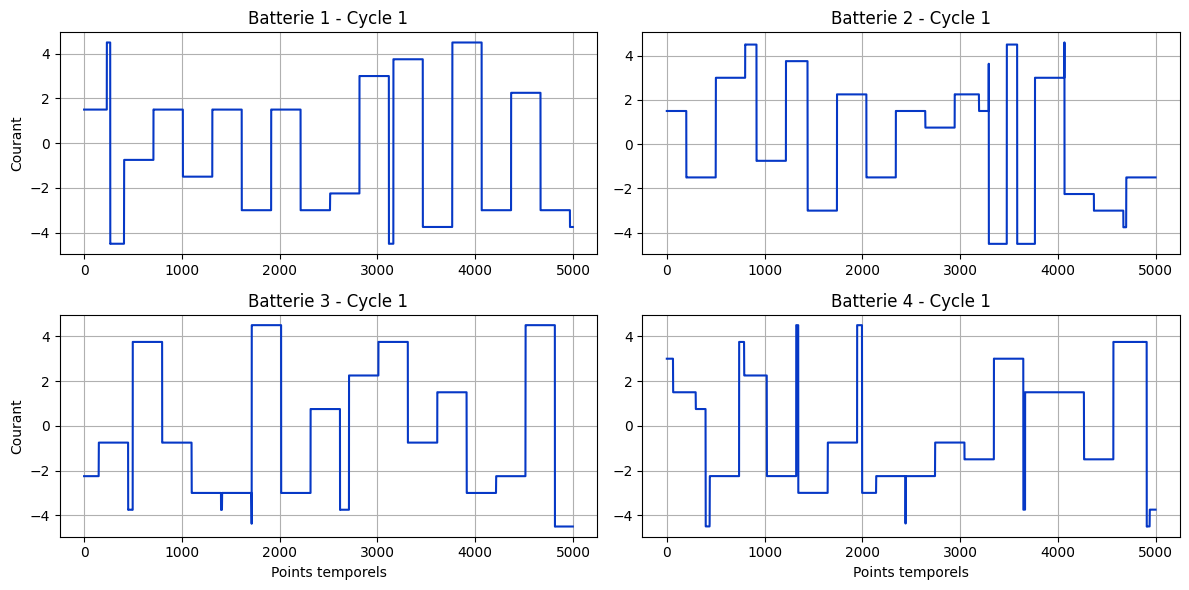

In [49]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(12, 6))

# Batterie 1
axs[0, 0].plot(battery1_df['Courant'].iloc[0] ,color = '#0638c6')
axs[0, 0].set_title("Batterie 1 - Cycle 1")
axs[0, 0].set_ylabel("Courant")
axs[0, 0].grid(True)

# Batterie 2
axs[0, 1].plot(battery2_df['Courant'].iloc[0],color = '#0638c6')
axs[0, 1].set_title("Batterie 2 - Cycle 1")
axs[0, 1].grid(True)

# Batterie 3
axs[1, 0].plot(battery3_df['Courant'].iloc[0],color = '#0638c6')
axs[1, 0].set_title("Batterie 3 - Cycle 1")
axs[1, 0].set_xlabel("Points temporels")
axs[1, 0].set_ylabel("Courant")
axs[1, 0].grid(True)

# Batterie 4
axs[1, 1].plot(battery4_df['Courant'].iloc[0],color = '#0638c6')
axs[1, 1].set_title("Batterie 4 - Cycle 1")
axs[1, 1].set_xlabel("Points temporels")
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()


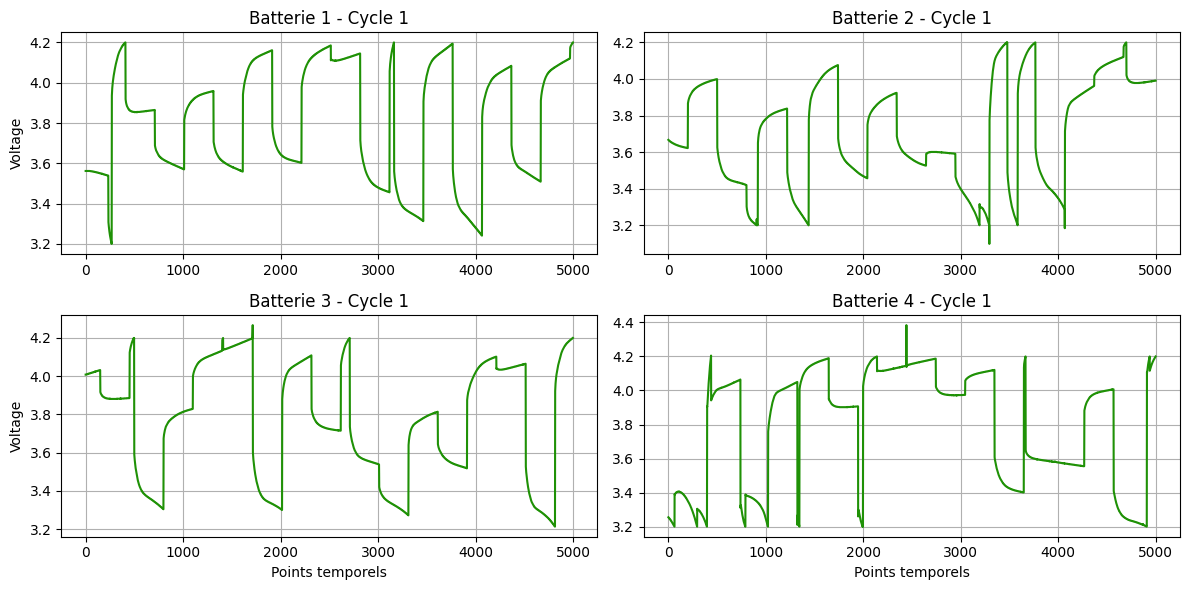

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(12, 6))

# Batterie 1
axs[0, 0].plot(battery1_df['Voltage'].iloc[0] , color = '#1f9106')
axs[0, 0].set_title("Batterie 1 - Cycle 1")
axs[0, 0].set_ylabel("Voltage")
axs[0, 0].grid(True)

# Batterie 2
axs[0, 1].plot(battery2_df['Voltage'].iloc[0], color = '#1f9106')
axs[0, 1].set_title("Batterie 2 - Cycle 1")
axs[0, 1].grid(True)

# Batterie 3
axs[1, 0].plot(battery3_df['Voltage'].iloc[0], color = '#1f9106')
axs[1, 0].set_title("Batterie 3 - Cycle 1")
axs[1, 0].set_xlabel("Points temporels")
axs[1, 0].set_ylabel("Voltage")
axs[1, 0].grid(True)

# Batterie 4
axs[1, 1].plot(battery4_df['Voltage'].iloc[0], color = '#1f9106')
axs[1, 1].set_title("Batterie 4 - Cycle 1")
axs[1, 1].set_xlabel("Points temporels")
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()


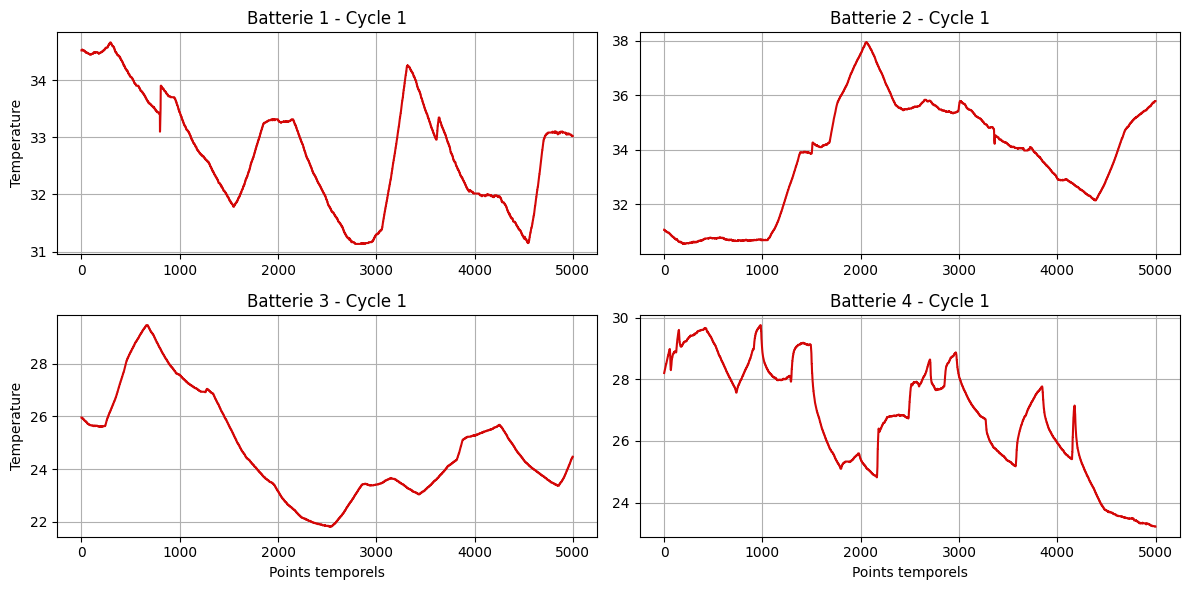

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(12, 6))

# Batterie 1
axs[0, 0].plot(battery1_df['Temperature'].iloc[14], color = '#d30707')
axs[0, 0].set_title("Batterie 1 - Cycle 1")
axs[0, 0].set_ylabel("Temperature")
axs[0, 0].grid(True)

# Batterie 2
axs[0, 1].plot(battery2_df['Temperature'].iloc[14], color = '#d30707')
axs[0, 1].set_title("Batterie 2 - Cycle 1")
axs[0, 1].grid(True)

# Batterie 3
axs[1, 0].plot(battery3_df['Temperature'].iloc[14], color = '#d30707')
axs[1, 0].set_title("Batterie 3 - Cycle 1")
axs[1, 0].set_xlabel("Points temporels")
axs[1, 0].set_ylabel("Temperature")
axs[1, 0].grid(True)

# Batterie 4
axs[1, 1].plot(battery4_df['Temperature'].iloc[14], color = '#d30707')
axs[1, 1].set_title("Batterie 4 - Cycle 1")
axs[1, 1].set_xlabel("Points temporels")
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()


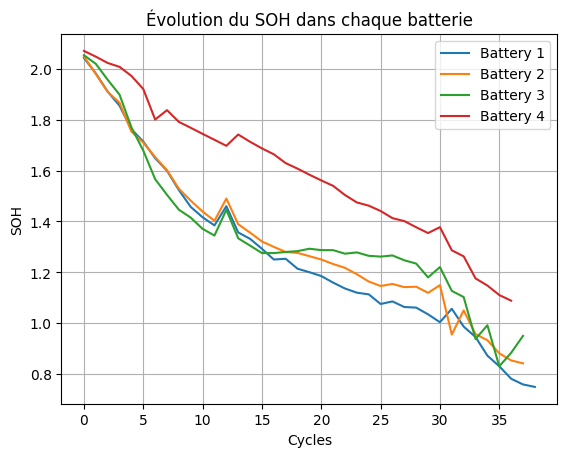

In [ ]:
import matplotlib.pyplot as plt


batteries = [battery1_df , battery2_df , battery3_df , battery4_df]
for i, battery in enumerate(batteries):
    soh = battery['Y'].values
    plt.plot(soh, label=f'Battery {i+1}')
plt.title("Évolution du SOH dans chaque batterie")
plt.xlabel("Cycles")
plt.ylabel("SOH")
plt.legend()
plt.grid()
plt.show()

# BILAN

la batterie 4 (en rouge) présente une évolution de capacité nettement différente des autres. Alors que les batteries 1, 2 et 3 suivent une tendance décroissante régulière, la batterie 4 montre une dégradation plus lente et moins cohérente. Ce comportement atypique explique les mauvaises performances du modèle lorsqu’elle est utilisée en test, justifiant ainsi l’analyse spécifique réalisée par la suite.

# Improvement techniques
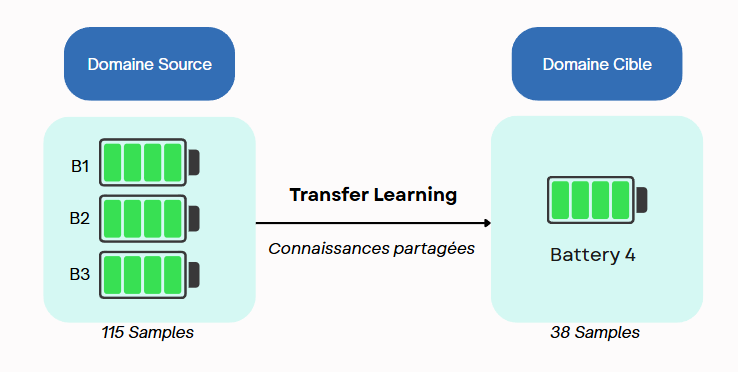


In [50]:
#function avec les poinds

def train_and_evaluate_weights(X_train, y_train, X_test, y_test, model_name="BayesianRidge", sample_weight=None):
    from sklearn.linear_model import BayesianRidge, Ridge, LinearRegression
    from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
    from sklearn.neural_network import MLPRegressor
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

    models = {
        "BayesianRidge": BayesianRidge(),
        "Ridge": Ridge(),
        "LinearRegression": LinearRegression(),
        "GradientBoosting": GradientBoostingRegressor(),
        "RandomForest": RandomForestRegressor(),
        "MLP": MLPRegressor()
    }

    model = models[model_name]

    # Entrainement du modele, avec ou sans sample_weight
    if sample_weight is not None:
        model.fit(X_train, y_train, sample_weight=sample_weight)
    #Sinon, apprentissage standard
    else:
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    return mse, r2, mape, y_pred


# Aproche 1

# Strategy 1

In [51]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

# Dictionnaire des batteries
batteries = {
    "B1": b1_minmax,
    "B2": b2_minmax,
    "B3": b3_minmax,
    "B4": b4_minmax
}

results = []
chosen_model = "BayesianRidge"

for battery in batteries.keys():
    print(f"===== Iteration : {battery} =====")

    test_battery = batteries[battery]
    y_test = test_battery['Y']
    X_test = test_battery.drop(columns='Y')

    train_batteries = [k for k in batteries.keys() if k != battery]
    train_df = pd.concat([v for k, v in batteries.items() if k != battery])
    y_train = train_df['Y']
    X_train = train_df.drop(columns='Y')

    sample_weight = np.ones(len(X_train))

    # Si la batterie testée est B4, appliquer le pondération
    if battery == "B4":
        print("→ B4 est en test, application du Weighted Training")
        # on va creer les domaines : Domaine Source B1+B2+B3 et Domaine Cible B4

        b4_values = X_test.values
        train_sources = pd.concat([pd.Series([k] * len(v), index=v.index) for k, v in batteries.items() if k != battery])

        #Boucler les lignes et les valeurs
        for i, row_b4 in enumerate(b4_values):
            max_sim = -1
            best_idx_global = None

            #k : quelle batterie appartient chaque ligne

            for name, df in [(k, batteries[k]) for k in train_batteries]:
                data = df.drop(columns='Y').values
                sims = cosine_similarity(row_b4.reshape(1, -1), data)[0]
                max_idx = np.argmax(sims)
                sim_value = sims[max_idx]

                df_index = df.index[max_idx]
                global_index = train_df.index.get_loc(df_index)

                if sim_value > max_sim:
                    max_sim = sim_value
                    best_idx_global = global_index

            if best_idx_global is not None:
                sample_weight[best_idx_global] *= 10

    # Entraînement du modèle
    mse, r2, mape, y_pred = train_and_evaluate_weights(
        X_train, y_train, X_test, y_test,
        model_name=chosen_model,
        sample_weight=sample_weight if battery == "B4" else None
    )

    results.append({
        "Test_Battery": battery,
        "MSE": mse * 100,
        "R2": r2 * 100,
        "MAPE": mape * 100 ,
        "sample_weight"  : sample_weight

    })

# Résumé
results_df = pd.DataFrame(results)

print("\n=== Résultats LOBO ===")
print(results_df)

print("\n--- Résumé global ---")
print(f"Model utilisé : {chosen_model}")
print(f"Moyenne R² : {results_df['R2'].mean():.4f}")
print(f"Moyenne MAPE : {results_df['MAPE'].mean():.4f}")
print(f"Moyenne MSE : {results_df['MSE'].mean():.4f}")


===== Iteration : B1 =====
===== Iteration : B2 =====
===== Iteration : B3 =====
===== Iteration : B4 =====
→ B4 est en test, application du Weighted Training

=== Résultats LOBO ===
  Test_Battery       MSE         R2       MAPE  \
0           B1  1.904976  83.330009  10.804503   
1           B2  0.726174  92.439468   4.502737   
2           B3  0.972420  88.383131   6.114463   
3           B4  2.813578  59.856372   7.891121   

                                       sample_weight  
0  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...  
1  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...  
2  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...  
3  [10.0, 10.0, 10.0, 1.0, 10.0, 10.0, 1.0, 1.0, ...  

--- Résumé global ---
Model utilisé : BayesianRidge
Moyenne R² : 81.0022
Moyenne MAPE : 7.3282
Moyenne MSE : 1.6043


# Strategy 2

In [52]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import BayesianRidge, Ridge, LinearRegression

print("\n--- Strategie 2:  FINE-TUNING ---")

b1_minmax = normalize_dataframe(b1, method='minmax')
b2_minmax = normalize_dataframe(b2, method='minmax')
b3_minmax = normalize_dataframe(b3, method='minmax')
b4_minmax = normalize_dataframe(b4, method='minmax')

#Peparer les data
#B1&B2
X_b1 = b1_minmax.drop(columns='Y')
y_b1 = b1_minmax['Y']
X_b2 = b2_minmax.drop(columns='Y')
y_b2 = b2_minmax['Y']

#B3&B4
X_b3 = b3_minmax.drop(columns='Y')
y_b3 = b3_minmax['Y']
X_b4 = b4_minmax.drop(columns='Y')
y_b4 = b4_minmax['Y']

X_b4_train, X_b4_test, y_b4_train, y_b4_test = train_test_split(
    X_b4, y_b4, test_size=0.2, random_state=42
)

X_base = pd.concat([X_b1, X_b2, X_b3], ignore_index=True)
y_base = pd.concat([y_b1, y_b2, y_b3], ignore_index=True)

# Pretrained on B1+B2+B3
pretrained_model = MLPRegressor(
    hidden_layer_sizes=(256, 64),
    learning_rate_init=0.01,
    max_iter=1000,
    random_state=42
)
pretrained_model.fit(X_base, y_base)

# Evaluer Basline
y_b4_pred_base = pretrained_model.predict(X_b4)
baseline_r2 = r2_score(y_b4, y_b4_pred_base)
baseline_mape = mean_absolute_percentage_error(y_b4, y_b4_pred_base)

print(f"Baseline R² (avant fine-tuning): {baseline_r2:.4f}")
print(f"Baseline MAPE: {baseline_mape:.4f}")

# Fine Tuning
finetuned_model = MLPRegressor(
    hidden_layer_sizes=(256, 64),
    learning_rate_init=0.005,
    max_iter=200,
    warm_start=True,
    random_state=42
)

# juste pour la simulation de pretraitement
finetuned_model.fit(X_base, y_base)

#si le modele peut etre oublier les anciennes data
#X_finetune = pd.concat([X_base.sample(frac=0.3, random_state=42), X_b4], ignore_index=True)
#y_finetune = pd.concat([y_base.sample(frac=0.3, random_state=42), y_b4], ignore_index=True)

finetuned_model.partial_fit(X_b4_train, y_b4_train)

y_b4_pred_finetuned = finetuned_model.predict(X_b4_test)
finetuned_r2 = r2_score(y_b4_test, y_b4_pred_finetuned)
finetuned_mape = mean_absolute_percentage_error(y_b4_test, y_b4_pred_finetuned)
finetuned_mse = mean_squared_error(y_b4_test, y_b4_pred_finetuned)


print(f"Fine-tuned R²: {finetuned_r2:.4f}")
print(f"Fine-tuned MAPE: {finetuned_mape:.4f}")
print(f"Fine-tuned MSE: {finetuned_mse:.4f}")
print(f"Amélioration R²: {finetuned_r2 - baseline_r2:.4f}")


--- Strategie 2:  FINE-TUNING ---
Baseline R² (avant fine-tuning): 0.2061
Baseline MAPE: 0.1218
Fine-tuned R²: 0.8424
Fine-tuned MAPE: 0.0726
Fine-tuned MSE: 0.0133
Amélioration R²: 0.6364


# Strategy 3

In [53]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np



#data
b1_minmax = normalize_dataframe(b1, method='minmax')
b2_minmax = normalize_dataframe(b2, method='minmax')
b3_minmax = normalize_dataframe(b3, method='minmax')
b4_minmax = normalize_dataframe(b4, method='minmax')


batteries = {
    "B1": b1_minmax,
    "B2": b2_minmax,
    "B3": b3_minmax,
    "B4":b4_minmax
}

print("\n--- strategie 3: ENSEMBLE ADAPTATIF")

# Préparation des données B4
X_b4 = b4_minmax.drop(columns='Y')
y_b4 = b4_minmax['Y']

# Split B4 en train/test
X_b4_train, X_b4_test, y_b4_train, y_b4_test = train_test_split(
    X_b4, y_b4, test_size=0.2, random_state=42
)

print(X_b4_train.shape)
print(X_b4_test.shape)

# Données base (B1+B2+B3)
X_b1 = b1_minmax.drop(columns='Y')
y_b1 = b1_minmax['Y']
X_b2 = b2_minmax.drop(columns='Y')
y_b2 = b2_minmax['Y']
X_b3 = b3_minmax.drop(columns='Y')
y_b3 = b3_minmax['Y']

X_base = pd.concat([X_b1, X_b2, X_b3], ignore_index=True)
y_base = pd.concat([y_b1, y_b2, y_b3], ignore_index=True)

print(X_base.shape , y_base.shape)

# Entrainement du modele base
print("====== Entrainement du modele base...... ==========")
base_model = BayesianRidge()
base_model.fit(X_base, y_base)

y_pred_base = base_model.predict(X_b4_test)
r2_base = r2_score(y_b4_test, y_pred_base)
mape_base = mean_absolute_percentage_error(y_b4_test, y_pred_base)

print("R2:" , r2_base *100 )
print("MAPE:" , mape_base *100 )


# Entraînement modèle spécialisé B4
print("\n====== Entrainement du model specific...... ==========")

b4_specific_model = BayesianRidge()
b4_specific_model.fit(X_b4_train, y_b4_train)

y_pred_b4_spec = b4_specific_model.predict(X_b4_test)
r2_spec = r2_score(y_b4_test, y_pred_b4_spec)
mape_spec = mean_absolute_percentage_error(y_b4_test, y_pred_b4_spec)
print("R2:" , r2_spec *100 )
print("MAPE:" , mape_spec *100 )

print("\n====== Entrainement du model ensemble...... ==========")



alpha = 0.3
y_pred_ensemble = alpha * y_pred_base + (1 - alpha) * y_pred_b4_spec

print(y_pred_ensemble)
print(len(y_pred_ensemble))
r2_ensemble = r2_score(y_b4_test, y_pred_ensemble)
mape_ensemble = mean_absolute_percentage_error(y_b4_test, y_pred_ensemble)
mse_enesemble = mean_squared_error(y_b4_test , y_pred_ensemble)

print("R2:" , r2_ensemble *100 )
print("MAPE:" , mape_ensemble *100 )
print("MSE:" , mse_enesemble *100 )



--- strategie 3: ENSEMBLE ADAPTATIF
(30, 14)
(8, 14)
(115, 14) (115,)
====== Entrainement du modele base...... ==========
R2: 52.32017903352221
MAPE: 11.882041980481258

====== Entrainement du model specific...... ==========
R2: 89.29852925154404
MAPE: 5.5069457704355385

====== Entrainement du model ensemble...... ==========
[1.20072903 1.19591694 1.77528334 1.6996734  1.29231659 1.31495074
 1.73657247 1.29841861]
8
R2: 87.60432633495023
MAPE: 6.039693420172504
MSE: 1.0500460401952925


# Approche 2 : Unsupervised

In [54]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

def create_autoencoder_1d(input_dim=5000, encoding_dim=100):

    # Encoder
    input_layer = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(1000, activation='relu')(input_layer)
    encoded = layers.Dense(500, activation='relu')(encoded)
    encoded = layers.Dense(encoding_dim, activation='relu')(encoded)  # Bottleneck

    # Decoder
    decoded = layers.Dense(500, activation='relu')(encoded)
    decoded = layers.Dense(1000, activation='relu')(decoded)
    decoded = layers.Dense(input_dim, activation='linear')(decoded)

    autoencoder = keras.Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')

    return autoencoder

In [55]:
list_batteries = [battery1_cleaned, battery2_cleaned, battery3_cleaned, battery4_cleaned]


In [56]:
def correct_battery4_autoencoder(list_batteries):

    print("=== CORRECTION BATTERY 4 AVEC AUTOENCODER ===")

    # Extraire les données
    battery1_cleaned, battery2_cleaned, battery3_cleaned, battery4_cleaned = list_batteries

    # Variables à corriger
    variables = ['Courant', 'Temperature', 'Voltage']

    # Copier Battery 4
    battery4_corrected = battery4_cleaned.copy()

    for var in variables:
        print(f"\nCorrection de {var}...")

        # data B1  , B2 et B3
        normal_data = []
        for battery in [battery1_cleaned, battery2_cleaned, battery3_cleaned]:
            for cycle_idx in range(len(battery)):
                series = np.array(battery[var].iloc[cycle_idx])
                normal_data.append(series)

        normal_data = np.array(normal_data)
        print(f"  Données normales: {normal_data.shape}")

        b4_data = []
        for cycle_idx in range(len(battery4_cleaned)):
            series = np.array(battery4_cleaned[var].iloc[cycle_idx])
            b4_data.append(series)

        b4_data = np.array(b4_data)
        print(f"  Données B4: {b4_data.shape}")

        scaler = MinMaxScaler()
        normal_data_scaled = scaler.fit_transform(normal_data)
        b4_data_scaled = scaler.transform(b4_data)

        #  Créer et entraîner autoencoder
        autoencoder = create_autoencoder_1d()

        # Train
        autoencoder.fit(
            normal_data_scaled, normal_data_scaled,
            epochs=50,
            batch_size=16,
            verbose=0
        )

        # Reconstruct B4
        b4_reconstructed_scaled = autoencoder.predict(b4_data_scaled, verbose=0)
        b4_reconstructed = scaler.inverse_transform(b4_reconstructed_scaled)

        # Mélange original + reconstruit
        correction_strength = 0.5
        b4_corrected = (1 - correction_strength) * b4_data + correction_strength * b4_reconstructed

        #  Remplacer dans le DataFrame
        for cycle_idx in range(len(battery4_corrected)):
            battery4_corrected.at[cycle_idx, var] = b4_corrected[cycle_idx]

        print(f"{var} corrigé")

    print(f"\nBattery 4 corrigée: {battery4_corrected.shape}")
    return battery4_corrected

In [57]:
battery4_corrected = correct_battery4_autoencoder(list_batteries)

=== CORRECTION BATTERY 4 AVEC AUTOENCODER ===

Correction de Courant...
  Données normales: (115, 5000)
  Données B4: (38, 5000)
Courant corrigé

Correction de Temperature...
  Données normales: (115, 5000)
  Données B4: (38, 5000)
Temperature corrigé

Correction de Voltage...
  Données normales: (115, 5000)
  Données B4: (38, 5000)


Voltage corrigé

Battery 4 corrigée: (38, 5)


In [58]:
def extract_features(df):
    features = pd.DataFrame()

    for col in ['Courant', 'Temperature', 'Voltage', 'Time']:
        features[f'{col}_mean'] = df[col].apply(lambda x: np.mean(x))
        features[f'{col}_std'] = df[col].apply(lambda x: np.std(x))
        features[f'{col}_min'] = df[col].apply(lambda x: np.min(x))
        features[f'{col}_max'] = df[col].apply(lambda x: np.max(x))
        features[f'{col}_median'] = df[col].apply(lambda x: np.median(x))

    # Corriger la ligne Y
    features['Y'] = df['Y'].apply(lambda x: float(x[0]) if isinstance(x, (list, np.ndarray)) and len(x) > 0 else float(x))

    return features



battery1_features = extract_features(battery1_cleaned)
battery2_features = extract_features(battery2_cleaned)
battery3_features = extract_features(battery3_cleaned)
battery4_features = extract_features(battery4_corrected)

print(battery1_features.shape)
print(battery2_features.shape)
print(battery3_features.shape)
print(battery4_features.shape)

#donnees pour 2eme approche
battery1_cleaned = battery1_cleaned.copy()
battery2_cleaned = battery2_cleaned.copy()
battery3_cleaned = battery3_cleaned.copy()
battery4_cleaned = battery4_corrected.copy() #B4 Reconstructed


(39, 21)
(38, 21)
(38, 21)
(38, 21)


In [59]:
sel1 = [ 'Voltage_min', 'Voltage_std', 'Voltage_max', 'Courant_max', 'Temperature_max', 'Courant_std',
        'Time_std', 'Temperature_mean', 'Time_min', 'Temperature_min',
        'Temperature_median', 'Time_median', 'Temperature_std', 'Time_mean' , 'Y']

# Filtrer les colonnes
b1 = battery1_features[sel1].copy()
b2 = battery2_features[sel1].copy()
b3 = battery3_features[sel1].copy()
b4 = battery4_features[sel1].copy()

print(b1.shape)
print(b2.shape)
print(b3.shape)
print(b4.shape)
print(b1.columns)

(39, 15)
(38, 15)
(38, 15)
(38, 15)
Index(['Voltage_min', 'Voltage_std', 'Voltage_max', 'Courant_max',
       'Temperature_max', 'Courant_std', 'Time_std', 'Temperature_mean',
       'Time_min', 'Temperature_min', 'Temperature_median', 'Time_median',
       'Temperature_std', 'Time_mean', 'Y'],
      dtype='object')


In [60]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd

def normalize_dataframe(df, method='minmax'):
    df_copy = df.copy()
    scaler = MinMaxScaler() if method == 'minmax' else StandardScaler()

    # Séparer X et Y
    X = df_copy.drop(columns='Y')
    y = df_copy['Y']

    # Normaliser X uniquement
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

    df_scaled = pd.concat([X_scaled, y], axis=1)
    return df_scaled

In [61]:
# MinMax
b1_minmax = normalize_dataframe(b1, method='minmax')
b2_minmax = normalize_dataframe(b2, method='minmax')
b3_minmax = normalize_dataframe(b3, method='minmax')
b4_minmax = normalize_dataframe(b4, method='minmax')

# Dictionnaire des batteries
batteries = {
    "B1": b1_minmax,
    "B2": b2_minmax,
    "B3": b3_minmax,
    "B4": b4_minmax
}

results = []
chosen_model = "BayesianRidge"
for test_battery in batteries.keys():
    test_df = batteries[test_battery]
    y_test = test_df['Y'].values
    X_test = test_df.drop(columns=['Y'])

    train_df = pd.concat([v for k, v in batteries.items() if k != test_battery])
    y_train = train_df['Y'].values
    X_train = train_df.drop(columns=['Y'])

    # Conversion explicite en float et remplissage NaN
    y_train = pd.Series(y_train).astype(float).fillna(pd.Series(y_train).astype(float).mean()).values
    y_test = pd.Series(y_test).astype(float).fillna(pd.Series(y_test).astype(float).mean()).values

    mse, r2, mape,pred = train_and_evaluate(X_train, y_train, X_test, y_test, model_name=chosen_model)

    results.append({
        "Test_Battery": test_battery,
        "MSE": mse,
        "R2": r2,
        "MAPE": mape
    })

results_df = pd.DataFrame(results)
print(results_df)

print("\n--- Résumé global ---")
print(f"Model utilisé : {chosen_model}")
print(f"Moyenne R² : {results_df['R2'].mean():.4f}")
print(f"Moyenne MAPE : {results_df['MAPE'].mean():.4f}")

  Test_Battery       MSE        R2      MAPE
0           B1  0.012378  0.891684  0.087923
1           B2  0.005353  0.944272  0.044119
2           B3  0.010006  0.880468  0.061936
3           B4  0.020249  0.711096  0.070833

--- Résumé global ---
Model utilisé : BayesianRidge
Moyenne R² : 0.8569
Moyenne MAPE : 0.0662


R2 batterie 2 (test): 0.9443
R2 batterie 4 (test): 0.7111

TOP 10 FEATURES BATTERIE 2 :
6. Courant_std     : 0.2166
2. Voltage_std     : 0.0730
10. Temperature_min : 0.0349
3. Voltage_max     : 0.0221
12. Time_median     : 0.0213
7. Time_std        : 0.0184
5. Temperature_max : 0.0176
4. Courant_max     : 0.0170
1. Voltage_min     : 0.0118
11. Temperature_median : 0.0088


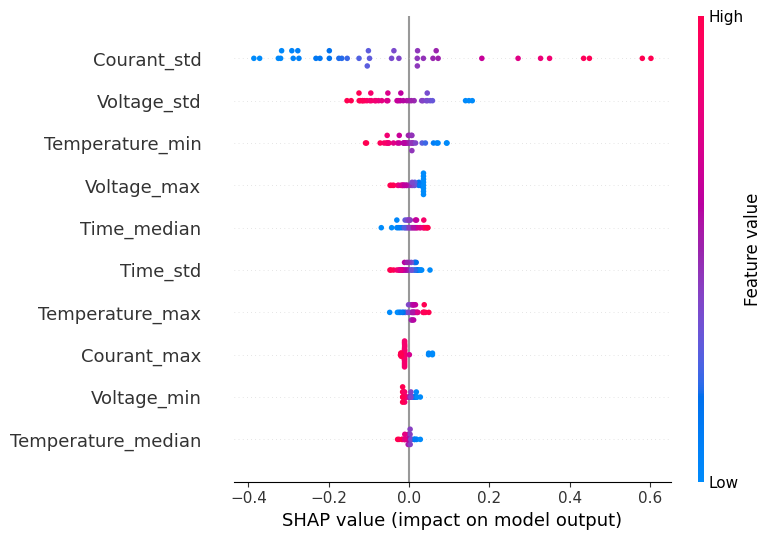

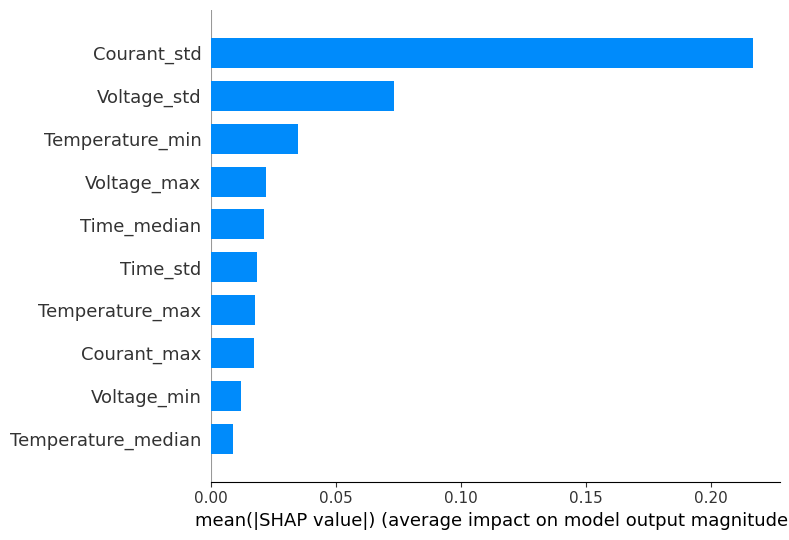

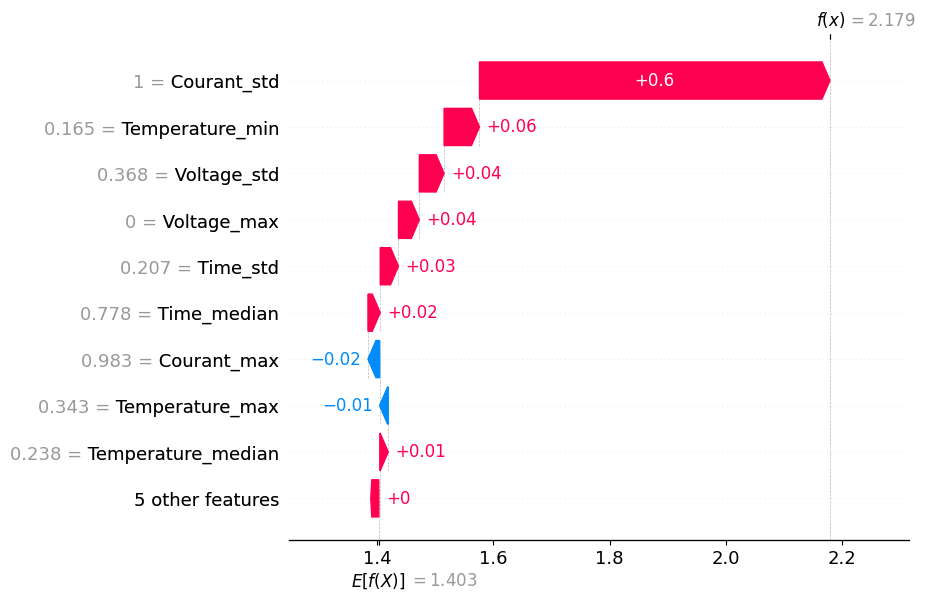


TOP 10 FEATURES BATTERIE 4 :
6. Courant_std     : 0.2232
2. Voltage_std     : 0.0777
10. Temperature_min : 0.0530
4. Courant_max     : 0.0386
5. Temperature_max : 0.0303
8. Temperature_mean : 0.0286
7. Time_std        : 0.0184
3. Voltage_max     : 0.0134
12. Time_median     : 0.0113
1. Voltage_min     : 0.0103


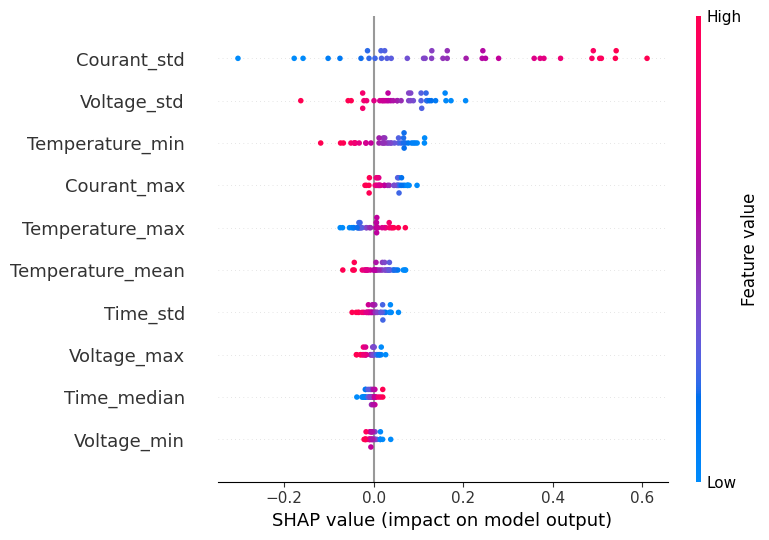

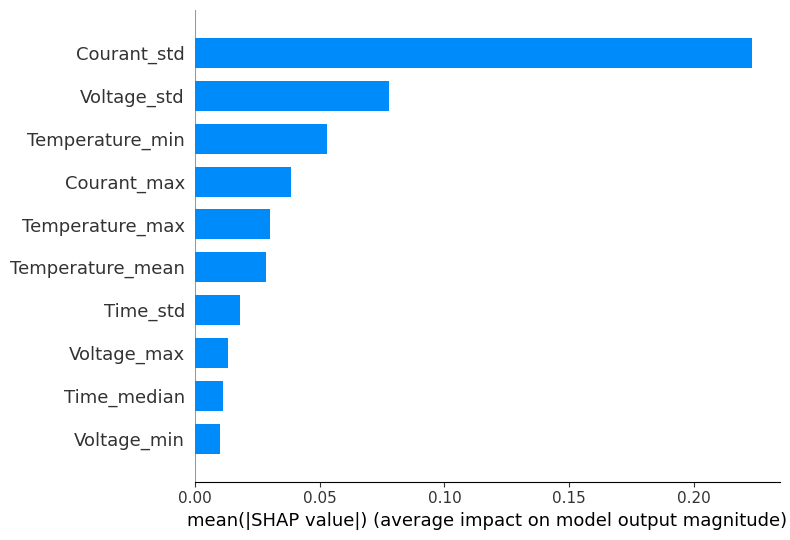

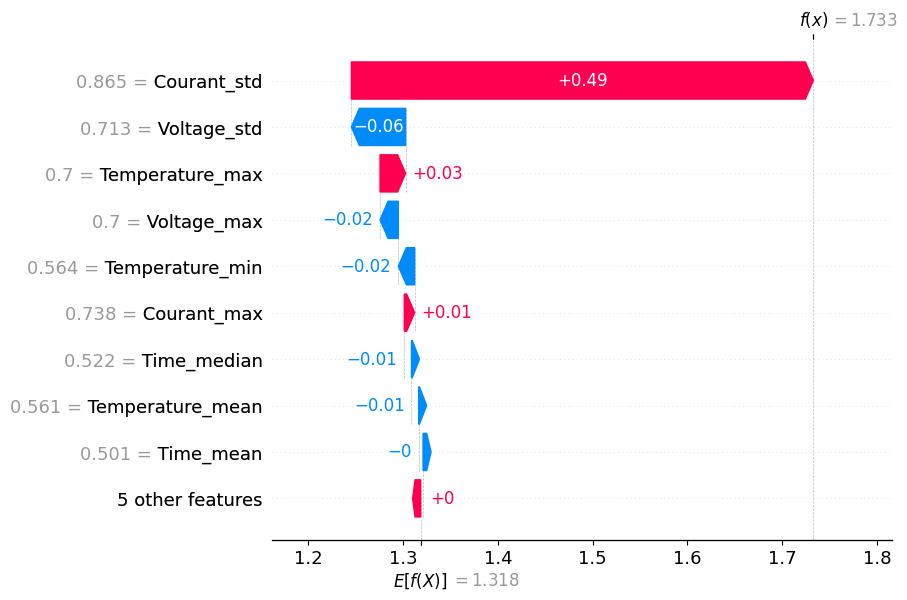

In [63]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import r2_score, mean_absolute_percentage_error

#data
b1_minmax = normalize_dataframe(b1, method='minmax')
b2_minmax = normalize_dataframe(b2, method='minmax')
b3_minmax = normalize_dataframe(b3, method='minmax')
b4_minmax = normalize_dataframe(b4, method='minmax')

# train (tout sauf B2)
train_dfs_b2 = [b1_minmax, b3_minmax, b4_minmax]
train_df_b2 = pd.concat(train_dfs_b2, ignore_index=True)
X_train_b2 = train_df_b2.drop(columns='Y')
y_train_b2 = train_df_b2['Y']

# train (tout sauf B4)
train_dfs_b4 = [b1_minmax, b2_minmax, b3_minmax]
train_df_b4 = pd.concat(train_dfs_b4, ignore_index=True)
X_train_b4 = train_df_b4.drop(columns='Y')
y_train_b4 = train_df_b4['Y']



# data test B2
X_test_b2 = b2_minmax.drop(columns='Y')
y_test_b2 = b2_minmax['Y']

# Data test B4
X_test_b4 = b4_minmax.drop(columns='Y')
y_test_b4 = b4_minmax['Y']

# M1
model_b2 = BayesianRidge()
model_b2.fit(X_train_b2, y_train_b2)

# P1
y_pred_b2 = model_b2.predict(X_test_b2)
r2_b2 = r2_score(y_test_b2, y_pred_b2)
print(f"R2 batterie 2 (test): {r2_b2:.4f}")

# M2
model_b4 = BayesianRidge()
model_b4.fit(X_train_b4, y_train_b4)

# P2
y_pred_b4 = model_b4.predict(X_test_b4)
r2_b4 = r2_score(y_test_b4, y_pred_b4)
print(f"R2 batterie 4 (test): {r2_b4:.4f}")

# ================ SHAP pour B2======================

explainer_b2 = shap.Explainer(model_b2, X_train_b2)
shap_values_b2 = explainer_b2(X_test_b2)

mean_abs_shap_b2 = np.abs(shap_values_b2.values).mean(axis=0)
feature_importance_b2 = pd.DataFrame({
    'Feature': X_test_b2.columns,
    'MeanAbsSHAP': mean_abs_shap_b2
}).sort_values(by='MeanAbsSHAP', ascending=False)

print("\nTOP 10 FEATURES BATTERIE 2 :")
for i, row in feature_importance_b2.head(10).iterrows():
    print(f"{i+1}. {row['Feature']:<15} : {row['MeanAbsSHAP']:.4f}")

# Plots SHAP batterie 2
shap.summary_plot(shap_values_b2, X_test_b2, max_display=10)
shap.summary_plot(shap_values_b2, X_test_b2, plot_type='bar', max_display=10)
shap.plots.waterfall(shap_values_b2[0])  # 1ere

# ================ SHAP pour B4======================

explainer_b4 = shap.Explainer(model_b4, X_train_b4)
shap_values_b4 = explainer_b4(X_test_b4)

mean_abs_shap_b4 = np.abs(shap_values_b4.values).mean(axis=0)
feature_importance_b4 = pd.DataFrame({
    'Feature': X_test_b4.columns,
    'MeanAbsSHAP': mean_abs_shap_b4
}).sort_values(by='MeanAbsSHAP', ascending=False)

print("\nTOP 10 FEATURES BATTERIE 4 :")
for i, row in feature_importance_b4.head(10).iterrows():
    print(f"{i+1}. {row['Feature']:<15} : {row['MeanAbsSHAP']:.4f}")

# Plots SHAP batterie 4
shap.summary_plot(shap_values_b4, X_test_b4, max_display=10)
shap.summary_plot(shap_values_b4, X_test_b4, plot_type='bar', max_display=10)
shap.plots.waterfall(shap_values_b4[0])  # Première instance


===== Iteration 1 =====
Train = B2 + B3 + B4, Test = B1

===== Iteration 2 =====
Train = B1 + B3 + B4, Test = B2

===== Iteration 3 =====
Train = B1 + B2 + B4, Test = B3

===== Iteration 4 =====
Train = B1 + B2 + B3, Test = B4



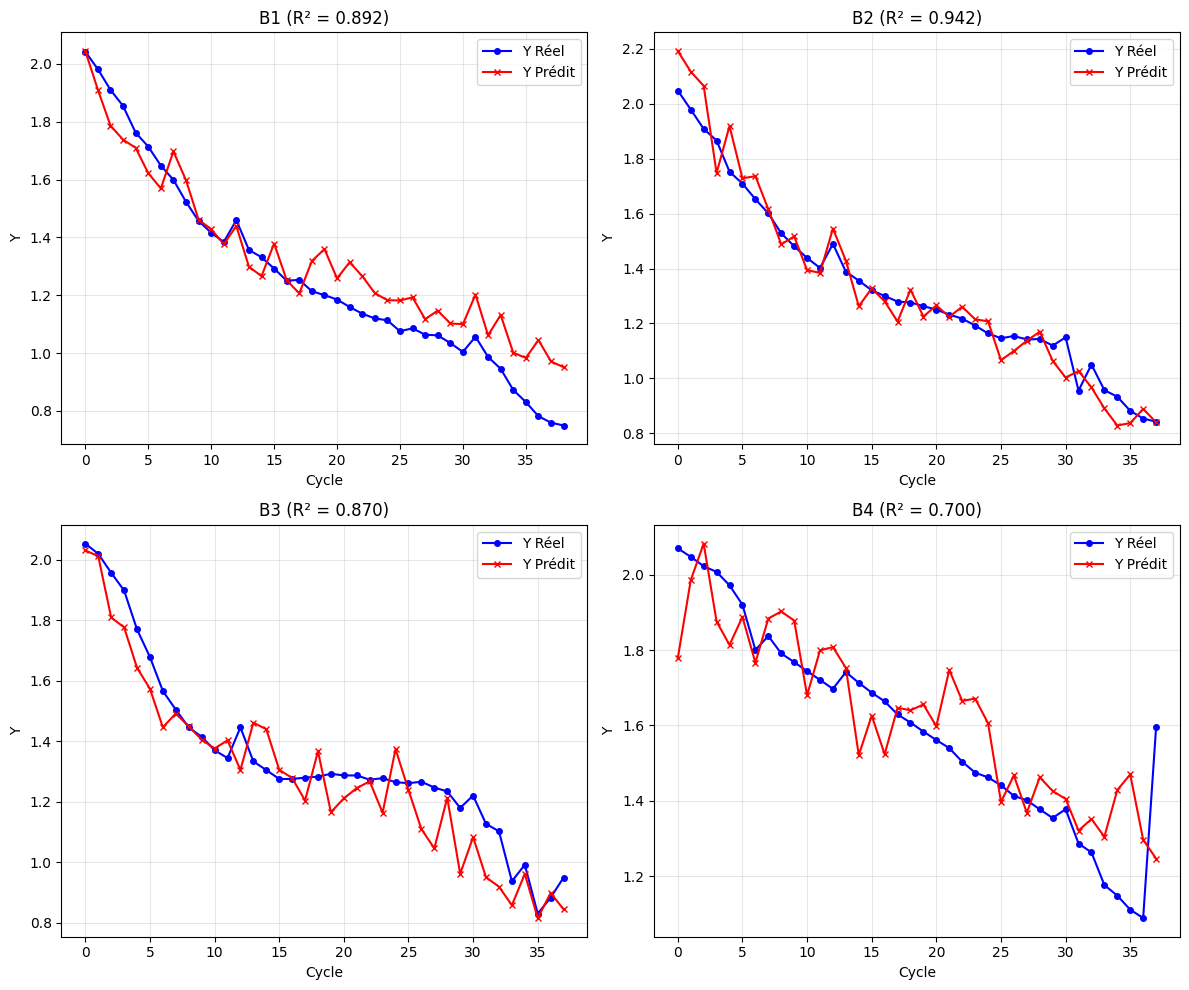

  Test_Battery       MSE      R2   MAPE
0           B1  0.012371  89.17%  8.77%
1           B2  0.005568  94.20%  4.44%
2           B3  0.010911  86.97%  6.44%
3           B4  0.021051  69.97%  7.64%

--- Résumé global ---
Model utilisé : LinearRegression
Moyenne MSE : 0.012475
Moyenne R² : 85.08%
Moyenne MAPE : 6.82%


In [64]:
import matplotlib.pyplot as plt



batteries = {
    "B1": b1_minmax,
    "B2": b2_minmax,
    "B3": b3_minmax,
    "B4": b4_minmax
}

results = []
#XGBoost , GradientBoosting , RandomForest , BayesianRidge , LinearRegression

chosen_model = "LinearRegression"
all_predictions = {}

iteration = 1
for test_battery in batteries.keys():
    print(f"===== Iteration {iteration} =====")

    train_batteries = [k for k in batteries.keys() if k != test_battery]
    print(f"Train = {' + '.join(train_batteries)}, Test = {test_battery}")

    test_df = batteries[test_battery]
    y_test = test_df['Y'].values
    X_test = test_df.drop(columns=['Y'])

    train_df = pd.concat([v for k, v in batteries.items() if k != test_battery])
    y_train = train_df['Y'].values
    X_train = train_df.drop(columns=['Y'])

    y_train = pd.Series(y_train).astype(float).fillna(pd.Series(y_train).astype(float).mean()).values
    y_test = pd.Series(y_test).astype(float).fillna(pd.Series(y_test).astype(float).mean()).values

    mse, r2, mape, y_pred = train_and_evaluate(X_train, y_train, X_test, y_test, model_name=chosen_model)

    all_predictions[test_battery] = {'y_test': y_test, 'y_pred': y_pred, 'r2': r2}

    results.append({
        "Test_Battery": test_battery,
        "MSE": mse,
        "R2": f"{r2*100:.2f}%",
        "MAPE": f"{mape*100:.2f}%"
    })

    iteration += 1
    print()

# Graphique
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (battery, data) in enumerate(all_predictions.items()):
    y_test = data['y_test']
    y_pred = data['y_pred']
    r2 = data['r2']

    # Créer les indices pour l'axe des x (numéro de cycle/point)
    x_indices = range(len(y_test))

    # Tracer les deux courbes
    axes[i].plot(x_indices, y_test, 'bo-', label='Y Réel', markersize=4)
    axes[i].plot(x_indices, y_pred, 'rx-', label='Y Prédit', markersize=4)

    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Y')
    axes[i].set_title(f'{battery} (R² = {r2:.3f})')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.savefig('predictions_vs_real.png', dpi=300, bbox_inches='tight')
plt.show()

results_df = pd.DataFrame(results)
print(results_df)

print("\n--- Résumé global ---")
print(f"Model utilisé : {chosen_model}")
print(f"Moyenne MSE : {np.mean([float(r['MSE']) for r in results]):.6f}")
print(f"Moyenne R² : {np.mean([float(r['R2'].rstrip('%'))/100 for r in results])*100:.2f}%")
print(f"Moyenne MAPE : {np.mean([float(r['MAPE'].rstrip('%'))/100 for r in results])*100:.2f}%")